In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

# Khởi tạo Spark Session
spark = SparkSession.builder.appName("HDFS_Interaction_Jupyter").getOrCreate()

print("Spark Session đã được khởi tạo thành công!")

Spark Session đã được khởi tạo thành công!


In [2]:
hdfs_path = "hdfs://master:9000/data/parquet"


=== PHÂN TÍCH HIGH-VOLUME FHVHV: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
Tổng số dòng ban đầu FHVHV: 239470448
Tổng số dòng sau khi lọc FHVHV: 229319569

=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (FHVHV) ===
+-------------------+-----------+----+------------+
|    pickup_datetime|pickup_date|hour|PULocationID|
+-------------------+-----------+----+------------+
|2024-01-01 00:28:08| 2024-01-01|   0|         161|
|2024-01-01 00:12:53| 2024-01-01|   0|         137|
|2024-01-01 00:23:05| 2024-01-01|   0|          79|
|2024-01-01 00:41:04| 2024-01-01|   0|         234|
|2024-01-01 00:57:21| 2024-01-01|   0|         148|
+-------------------+-----------+----+------------+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN FHVHV THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
+------------+----+-----+
|holiday_date|hour|count|
+------------+----+-----+
|2024-01-01  |0   |50224|
|2024-01-01  |1   |56404|
|2024-01-01  |2   |54156|
|2024-01-01  |3   |46380|
|2024-01-01  |4   |32246|
|2024-01-01  |5

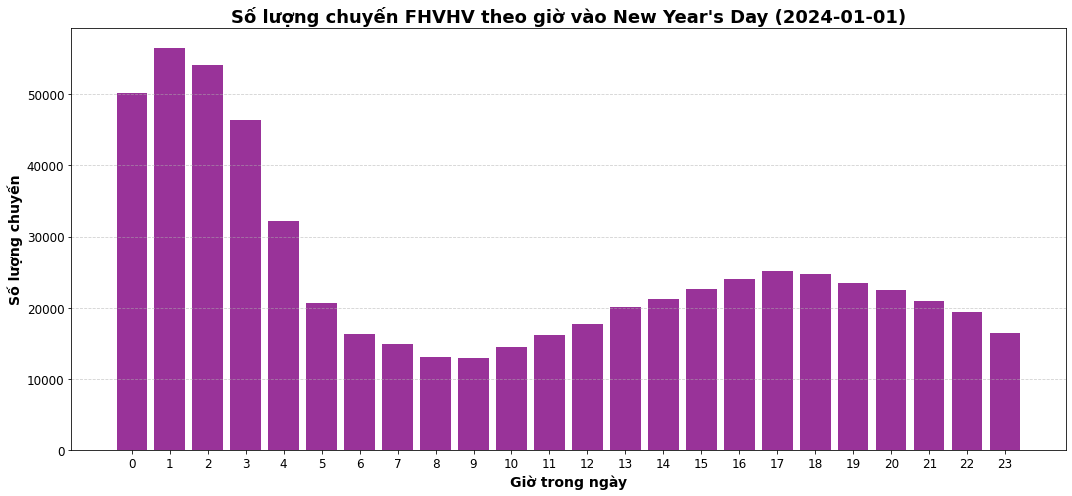


--- THỐNG KÊ CHI TIẾT CHO New Year's Day (2024-01-01) ---
Tổng số chuyến trong ngày: 606,433 chuyến
Giờ cao điểm: 1h (56,404 chuyến)


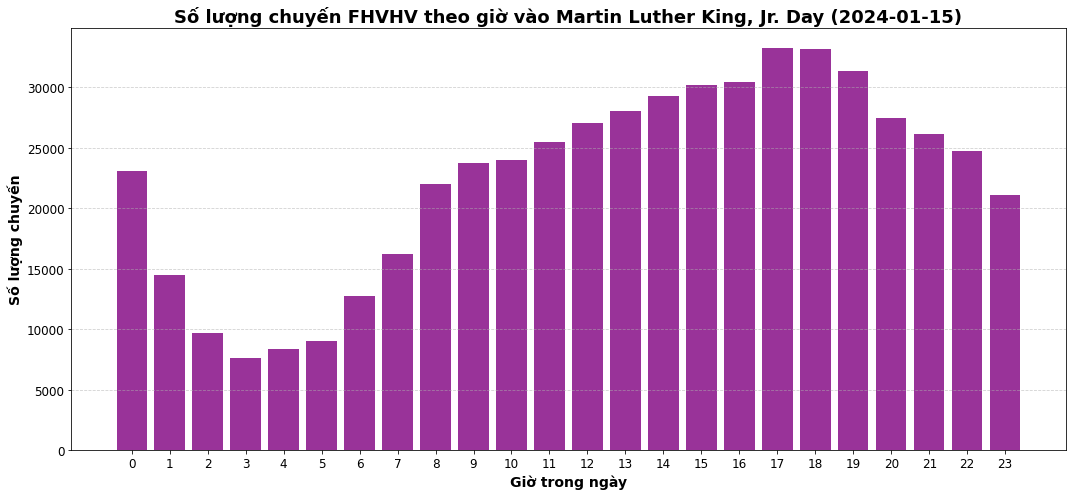


--- THỐNG KÊ CHI TIẾT CHO Martin Luther King, Jr. Day (2024-01-15) ---
Tổng số chuyến trong ngày: 538,656 chuyến
Giờ cao điểm: 17h (33,208 chuyến)


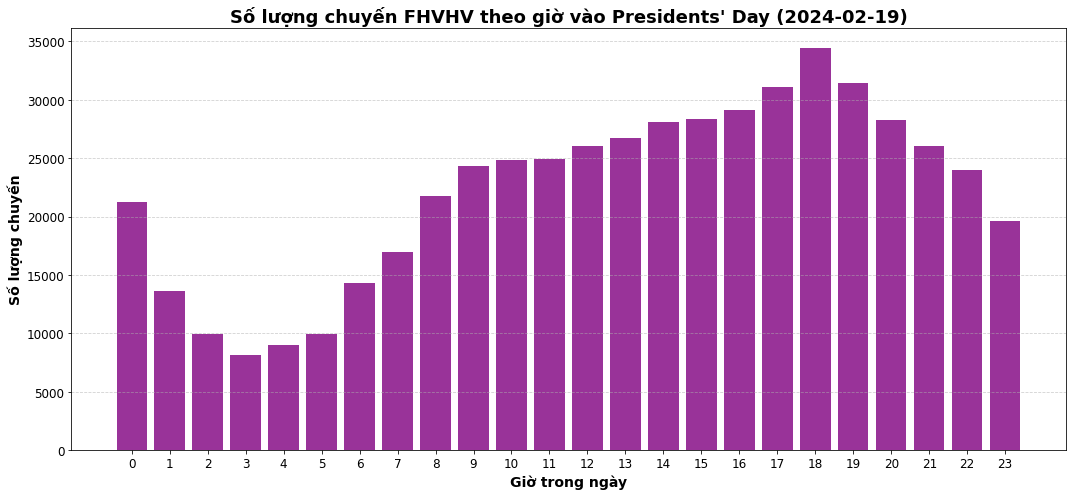


--- THỐNG KÊ CHI TIẾT CHO Presidents' Day (2024-02-19) ---
Tổng số chuyến trong ngày: 532,136 chuyến
Giờ cao điểm: 18h (34,382 chuyến)


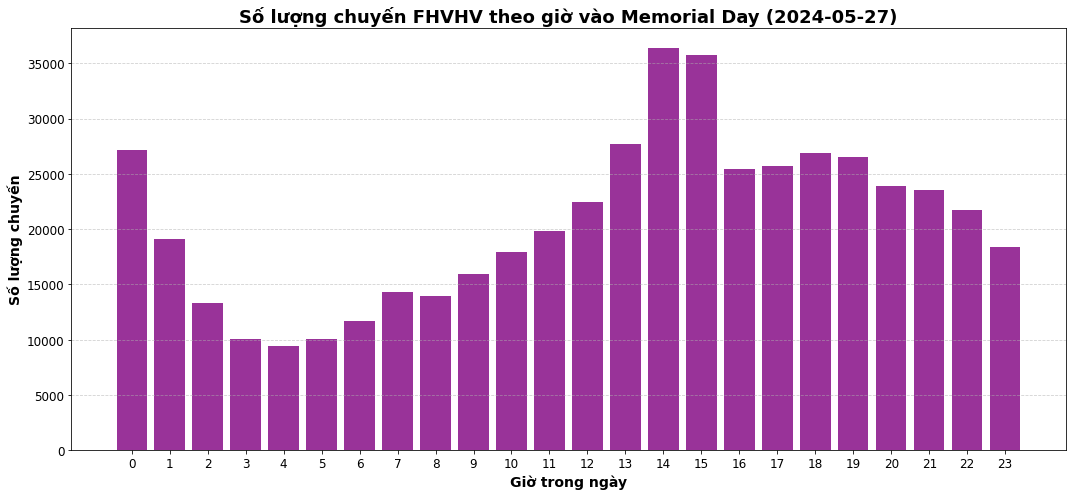


--- THỐNG KÊ CHI TIẾT CHO Memorial Day (2024-05-27) ---
Tổng số chuyến trong ngày: 497,348 chuyến
Giờ cao điểm: 14h (36,344 chuyến)


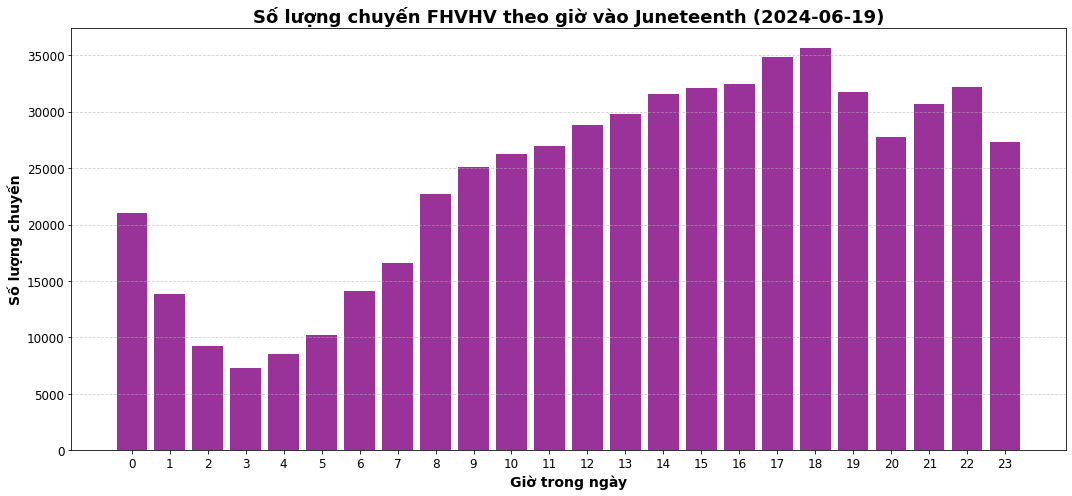


--- THỐNG KÊ CHI TIẾT CHO Juneteenth (2024-06-19) ---
Tổng số chuyến trong ngày: 576,470 chuyến
Giờ cao điểm: 18h (35,599 chuyến)


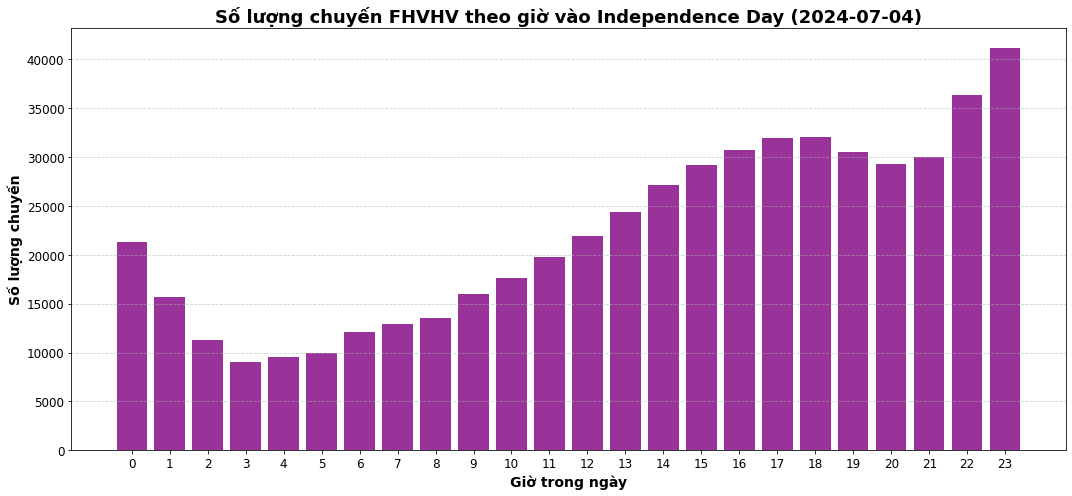


--- THỐNG KÊ CHI TIẾT CHO Independence Day (2024-07-04) ---
Tổng số chuyến trong ngày: 533,767 chuyến
Giờ cao điểm: 23h (41,111 chuyến)


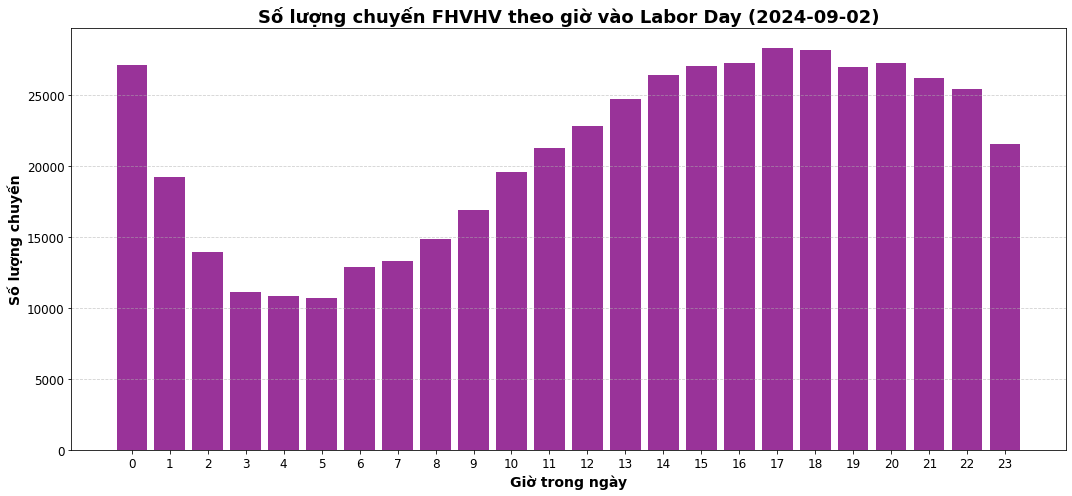


--- THỐNG KÊ CHI TIẾT CHO Labor Day (2024-09-02) ---
Tổng số chuyến trong ngày: 504,410 chuyến
Giờ cao điểm: 17h (28,290 chuyến)


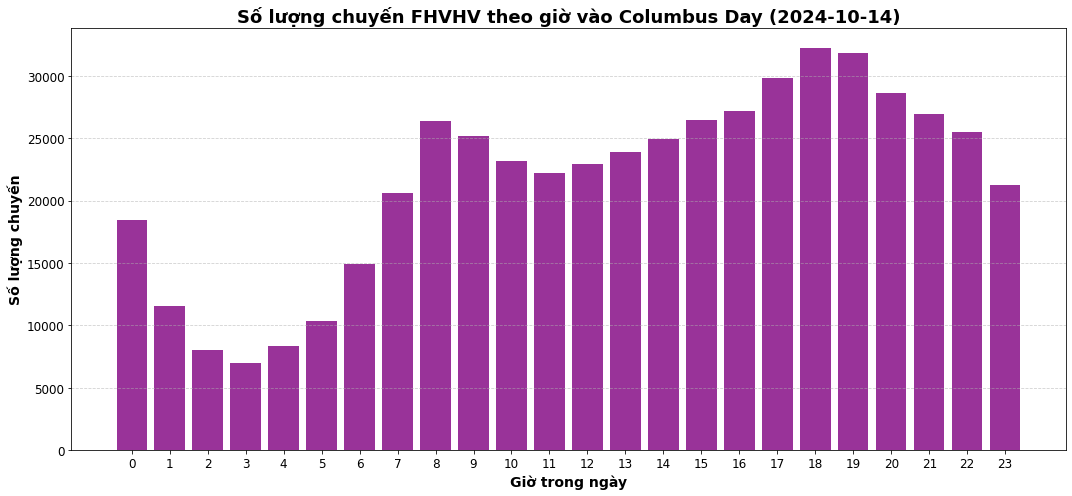


--- THỐNG KÊ CHI TIẾT CHO Columbus Day (2024-10-14) ---
Tổng số chuyến trong ngày: 517,750 chuyến
Giờ cao điểm: 18h (32,183 chuyến)


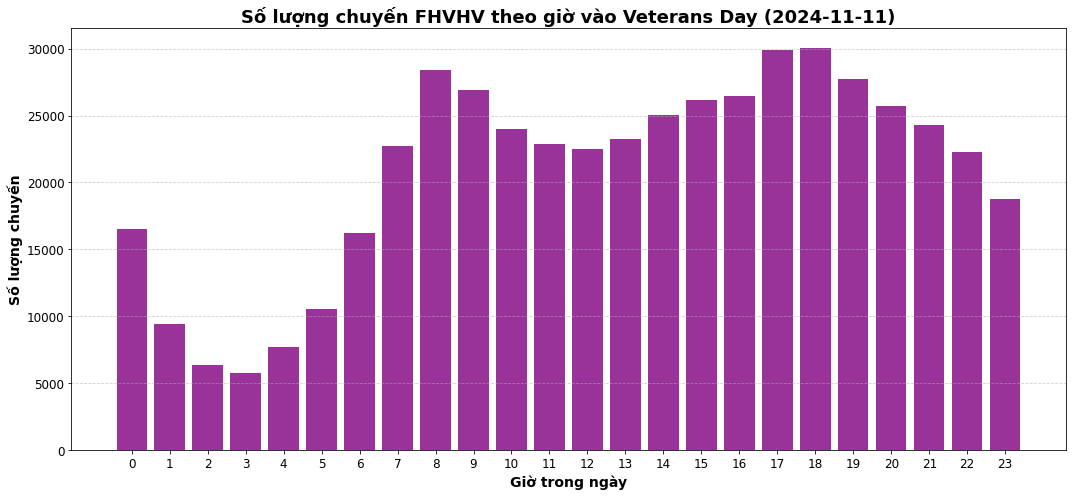


--- THỐNG KÊ CHI TIẾT CHO Veterans Day (2024-11-11) ---
Tổng số chuyến trong ngày: 499,729 chuyến
Giờ cao điểm: 18h (30,004 chuyến)


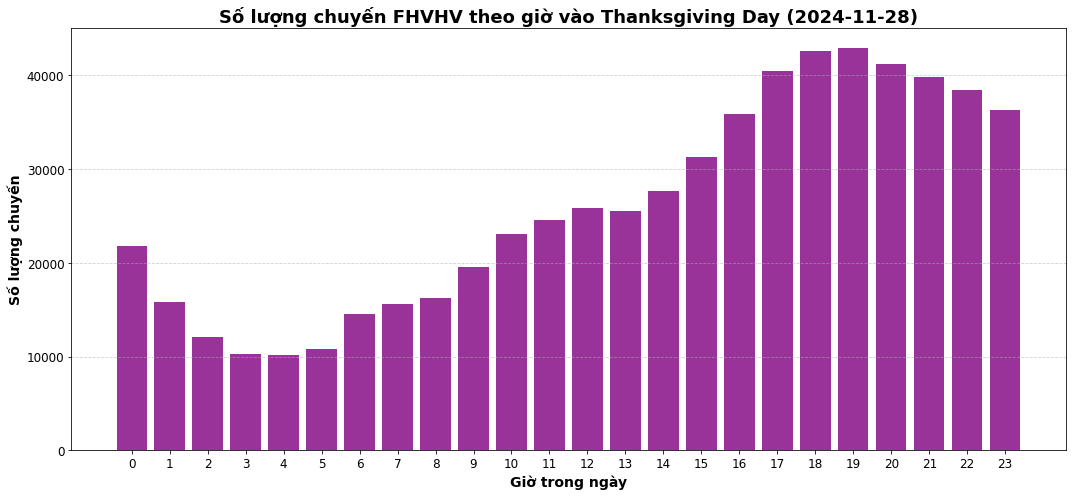


--- THỐNG KÊ CHI TIẾT CHO Thanksgiving Day (2024-11-28) ---
Tổng số chuyến trong ngày: 622,670 chuyến
Giờ cao điểm: 19h (42,862 chuyến)


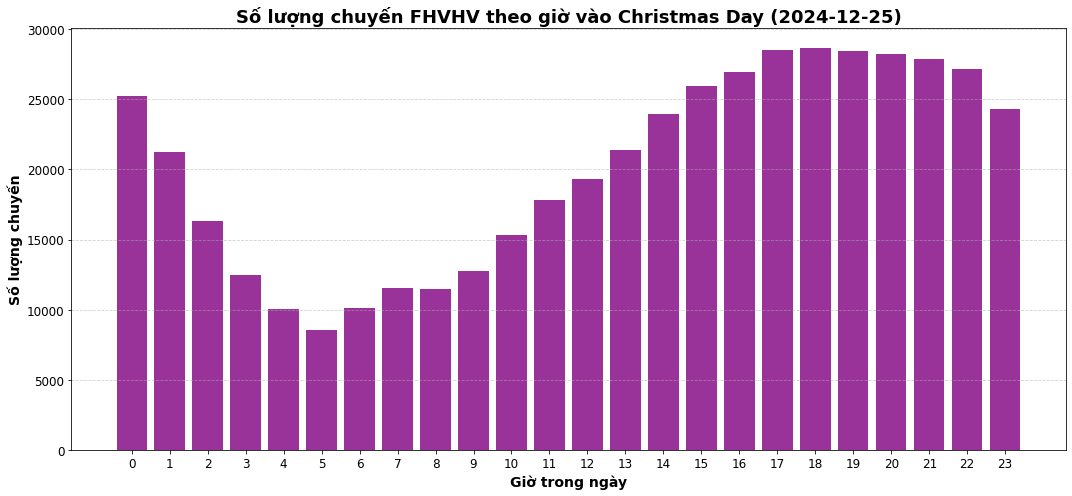


--- THỐNG KÊ CHI TIẾT CHO Christmas Day (2024-12-25) ---
Tổng số chuyến trong ngày: 483,712 chuyến
Giờ cao điểm: 18h (28,613 chuyến)


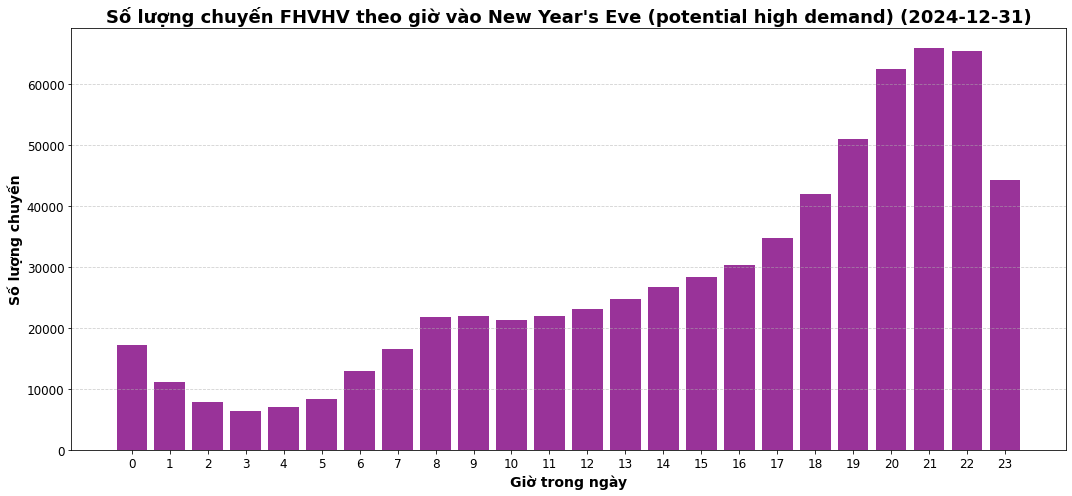


--- THỐNG KÊ CHI TIẾT CHO New Year's Eve (potential high demand) (2024-12-31) ---
Tổng số chuyến trong ngày: 674,201 chuyến
Giờ cao điểm: 21h (65,782 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT FHVHV ===


In [3]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour, date_format
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date

print("=== PHÂN TÍCH HIGH-VOLUME FHVHV: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")

# Đọc dữ liệu Parquet từ HDFS
df = spark.read.parquet("hdfs://master:9000/data/parquet/fhvhv_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu FHVHV: {df.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU (Giữ nguyên) ---
df_filtered = df.filter(
    (col("pickup_datetime").isNotNull()) &
    (col("dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_filtered = df_filtered.withColumn("pickup_ts", to_timestamp(col("pickup_datetime"))) \
                         .withColumn("dropoff_ts", to_timestamp(col("dropoff_datetime")))

df_filtered = df_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_filtered = df_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_filtered = df_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("calculated_trip_time_seconds") > 0, (col("trip_miles") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_filtered = df_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_miles") >= 0.1) & (col("trip_miles") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_filtered = df_filtered.filter(
    (col("base_passenger_fare") >= 0) & (col("base_passenger_fare") < 1000) &
    (col("tolls") >= 0) & (col("tolls") < 200) &
    (col("bcf") >= 0) & (col("bcf") < 100) &
    (col("sales_tax") >= 0) & (col("sales_tax") < 100) &
    (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20) &
    (col("airport_fee") >= 0) & (col("airport_fee") < 50) &
    (col("tips") >= 0) & (col("tips") < 300) &
    (col("driver_pay") >= 0) & (col("driver_pay") < 1000)
)

print(f"Tổng số dòng sau khi lọc FHVHV: {df_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_fhvhv = df_filtered.withColumn("pickup_ts", to_timestamp("pickup_datetime"))

# --- PHÂN TÍCH BỔ SUNG: SỐ LƯỢNG CHUYẾN THEO GIỜ TRONG TỪNG NGÀY LỄ CỤ THỂ (FHVHV) ---

# Bước 1: Định nghĩa các ngày lễ ở NYC năm 2024
nyc_holidays_2024_map = {
    date(2024, 1, 1): "New Year's Day",
    date(2024, 1, 15): "Martin Luther King, Jr. Day",
    date(2024, 2, 19): "Presidents' Day",
    date(2024, 5, 27): "Memorial Day",
    date(2024, 6, 19): "Juneteenth",
    date(2024, 7, 4): "Independence Day",
    date(2024, 9, 2): "Labor Day",
    date(2024, 10, 14): "Columbus Day",
    date(2024, 11, 11): "Veterans Day",
    date(2024, 11, 28): "Thanksgiving Day",
    date(2024, 12, 25): "Christmas Day",
    date(2024, 12, 31): "New Year's Eve (potential high demand)"
}
nyc_holiday_dates = list(nyc_holidays_2024_map.keys())

# Bước 2: Thêm cột `pickup_date`, `is_holiday` và `hour` vào DataFrame
df_fhvhv_with_holidays = df_cleaned_fhvhv.withColumn("pickup_date", to_date(col("pickup_ts"))) \
                                      .withColumn("hour", hour(col("pickup_ts")))

df_fhvhv_with_holidays = df_fhvhv_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holiday_dates), True).otherwise(False)
)

# Lọc chỉ các chuyến đi vào ngày lễ
df_holiday_trips_fhvhv = df_fhvhv_with_holidays.filter(col("is_holiday") == True)

print("\n=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (FHVHV) ===")
df_holiday_trips_fhvhv.select("pickup_datetime", "pickup_date", "hour", "PULocationID").show(5)

# Bước 3: Nhóm theo ngày lễ (dưới dạng date_format để hiển thị rõ ràng hơn) và giờ, sau đó đếm
df_fhvhv_holiday_hourly_counts = df_holiday_trips_fhvhv \
    .groupBy(date_format(col("pickup_date"), "yyyy-MM-dd").alias("holiday_date"), "hour") \
    .count() \
    .orderBy("holiday_date", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN FHVHV THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")
df_fhvhv_holiday_hourly_counts.show(df_fhvhv_holiday_hourly_counts.count(), False)

# Chuyển sang Pandas để vẽ biểu đồ cho từng ngày lễ
pdf_fhvhv_holiday_hourly = df_fhvhv_holiday_hourly_counts.toPandas()

# Vẽ biểu đồ cho từng ngày lễ
unique_holidays = pdf_fhvhv_holiday_hourly['holiday_date'].unique()

for holiday_date_str in unique_holidays:
    holiday_name = nyc_holidays_2024_map.get(date.fromisoformat(holiday_date_str), holiday_date_str)
    
    data_for_holiday = pdf_fhvhv_holiday_hourly[pdf_fhvhv_holiday_hourly['holiday_date'] == holiday_date_str].sort_values('hour')
    
    # --- BẮT ĐẦU PHẦN CODE ĐÃ THAY ĐỔI ---
    plt.figure(figsize=(15, 7)) # Tăng kích thước biểu đồ cho dễ nhìn hơn
    
    # Thay plt.plot bằng plt.bar
    plt.bar(data_for_holiday['hour'], data_for_holiday['count'], color='purple', alpha=0.8) 
    
    # Tăng kích thước phông chữ
    plt.title(f'Số lượng chuyến FHVHV theo giờ vào {holiday_name} ({holiday_date_str})', fontsize=18, fontweight='bold')
    plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
    plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
    plt.xticks(range(0, 24), fontsize=12) # Hiển thị tất cả các giờ
    plt.yticks(fontsize=12)
    
    plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.6)
    
    plt.ticklabel_format(style='plain', axis='y') # Đảm bảo không dùng ký hiệu khoa học
    
    plt.tight_layout()
    plt.show()
    # --- KẾT THÚC PHẦN CODE ĐÃ THAY ĐỔI ---

    print(f"\n--- THỐNG KÊ CHI TIẾT CHO {holiday_name} ({holiday_date_str}) ---")
    if not data_for_holiday.empty:
        total_trips_on_holiday = data_for_holiday['count'].sum()
        peak_hour_data = data_for_holiday.loc[data_for_holiday['count'].idxmax()]
        print(f"Tổng số chuyến trong ngày: {total_trips_on_holiday:,.0f} chuyến")
        print(f"Giờ cao điểm: {peak_hour_data['hour']:0.0f}h ({peak_hour_data['count']:,.0f} chuyến)")
    else:
        print("Không có dữ liệu chuyến đi nào cho ngày này.")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT FHVHV ===")

=== PHÂN TÍCH YELLOW TAXI: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
Tổng số dòng ban đầu Yellow Taxi: 41169720
Tổng số dòng sau khi lọc Yellow Taxi: 39107100

=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (YELLOW TAXI) ===
+--------------------+-----------+----+------------+
|tpep_pickup_datetime|pickup_date|hour|PULocationID|
+--------------------+-----------+----+------------+
| 2024-01-01 00:57:55| 2024-01-01|   0|         186|
| 2024-01-01 00:03:00| 2024-01-01|   0|         140|
| 2024-01-01 00:17:06| 2024-01-01|   0|         236|
| 2024-01-01 00:36:38| 2024-01-01|   0|          79|
| 2024-01-01 00:46:51| 2024-01-01|   0|         211|
+--------------------+-----------+----+------------+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN YELLOW TAXI THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
+------------+----+-----+
|holiday_date|hour|count|
+------------+----+-----+
|2024-01-01  |0   |6100 |
|2024-01-01  |1   |6570 |
|2024-01-01  |2   |5369 |
|2024-01-01  |3   |4284 |
|2024-01-01  |4 

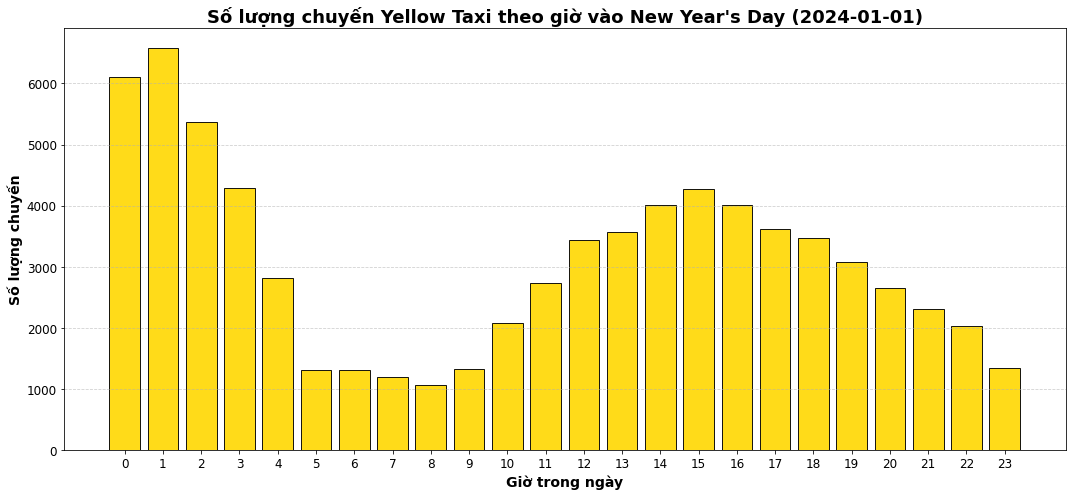


--- THỐNG KÊ CHI TIẾT CHO New Year's Day (2024-01-01) ---
Tổng số chuyến trong ngày: 73,964 chuyến
Giờ cao điểm: 1h (6,570 chuyến)


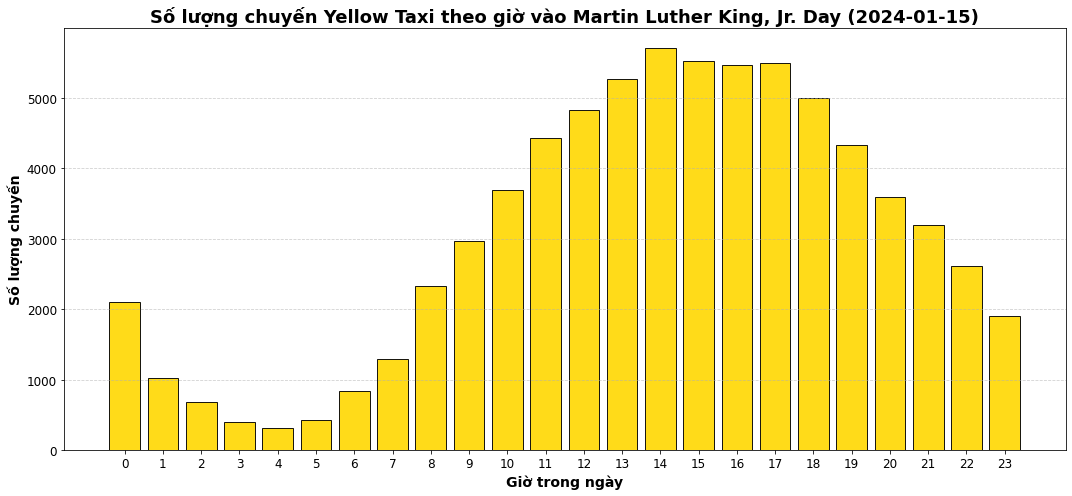


--- THỐNG KÊ CHI TIẾT CHO Martin Luther King, Jr. Day (2024-01-15) ---
Tổng số chuyến trong ngày: 73,521 chuyến
Giờ cao điểm: 14h (5,703 chuyến)


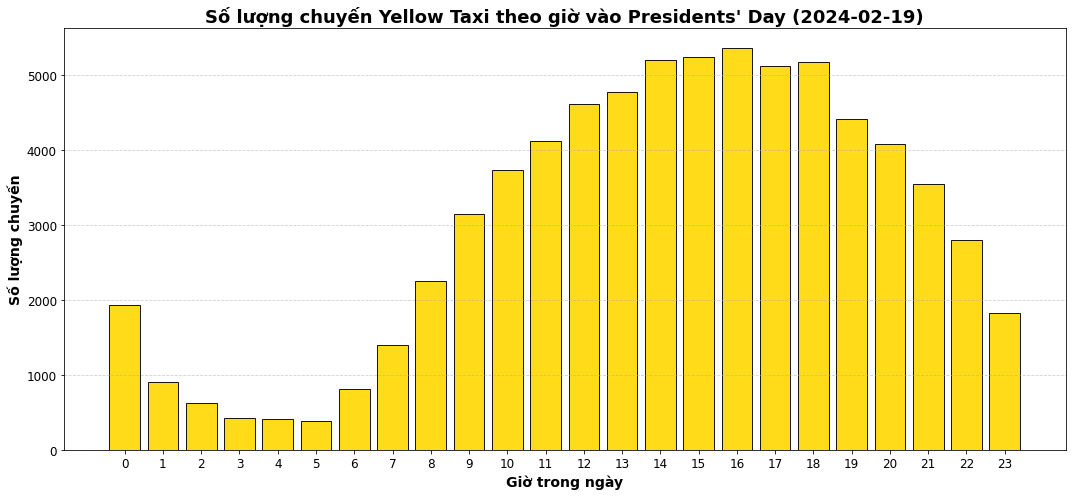


--- THỐNG KÊ CHI TIẾT CHO Presidents' Day (2024-02-19) ---
Tổng số chuyến trong ngày: 72,297 chuyến
Giờ cao điểm: 16h (5,350 chuyến)


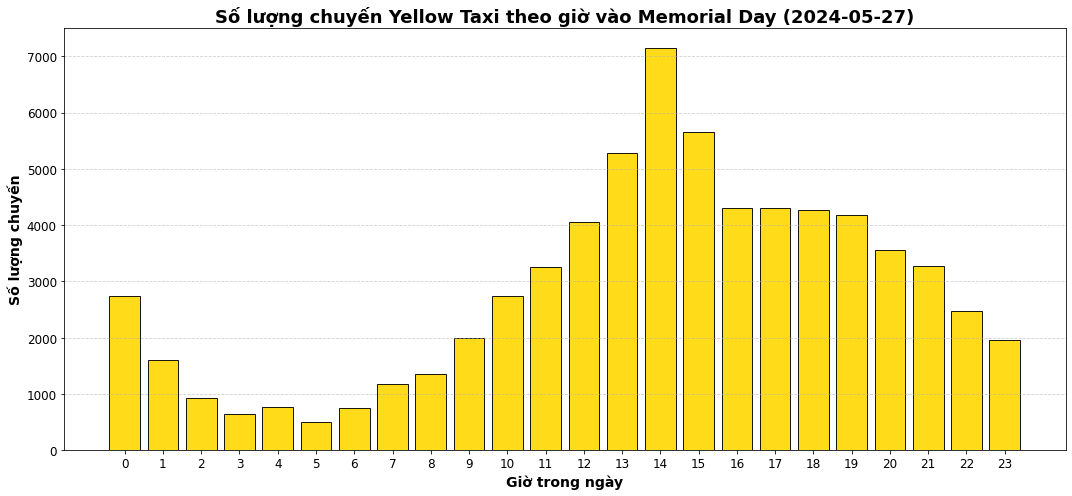


--- THỐNG KÊ CHI TIẾT CHO Memorial Day (2024-05-27) ---
Tổng số chuyến trong ngày: 68,972 chuyến
Giờ cao điểm: 14h (7,141 chuyến)


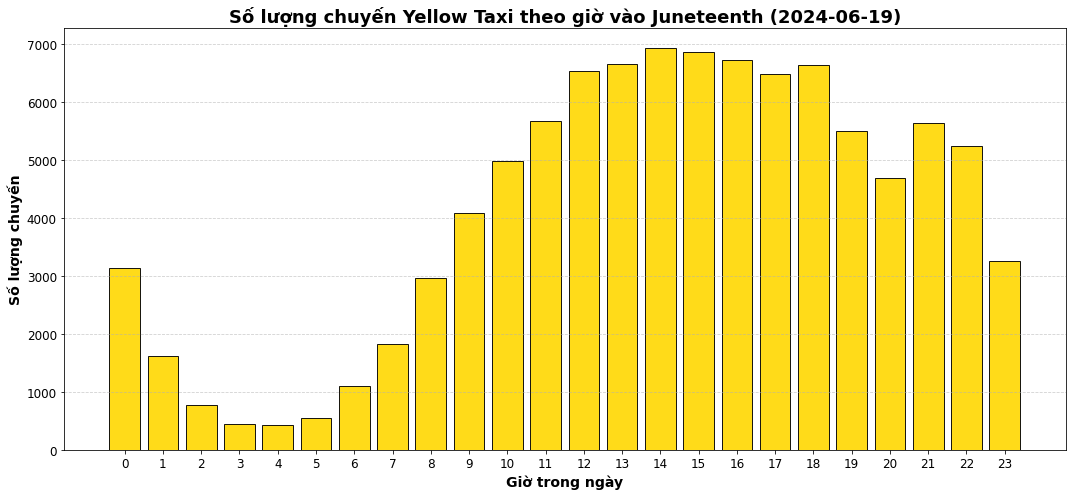


--- THỐNG KÊ CHI TIẾT CHO Juneteenth (2024-06-19) ---
Tổng số chuyến trong ngày: 98,731 chuyến
Giờ cao điểm: 14h (6,921 chuyến)


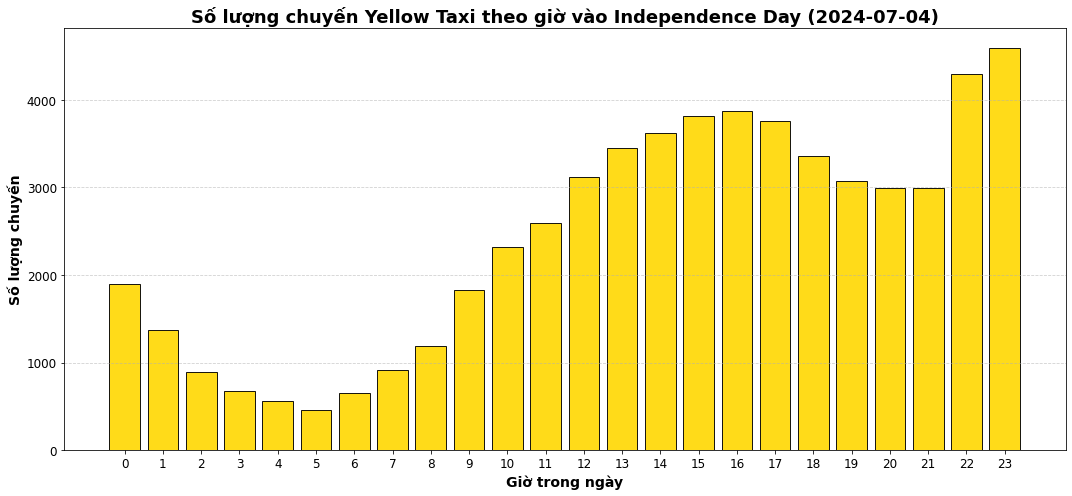


--- THỐNG KÊ CHI TIẾT CHO Independence Day (2024-07-04) ---
Tổng số chuyến trong ngày: 58,299 chuyến
Giờ cao điểm: 23h (4,585 chuyến)


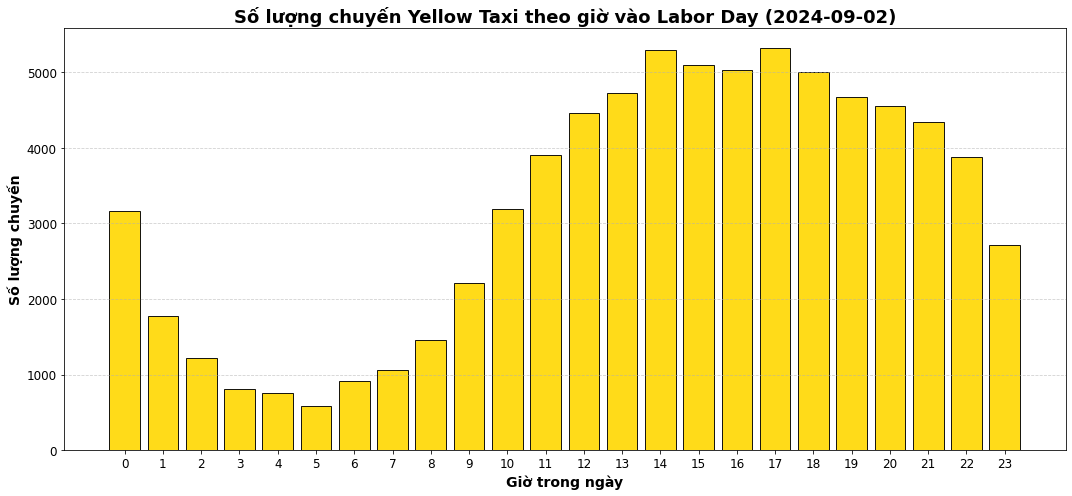


--- THỐNG KÊ CHI TIẾT CHO Labor Day (2024-09-02) ---
Tổng số chuyến trong ngày: 76,126 chuyến
Giờ cao điểm: 17h (5,312 chuyến)


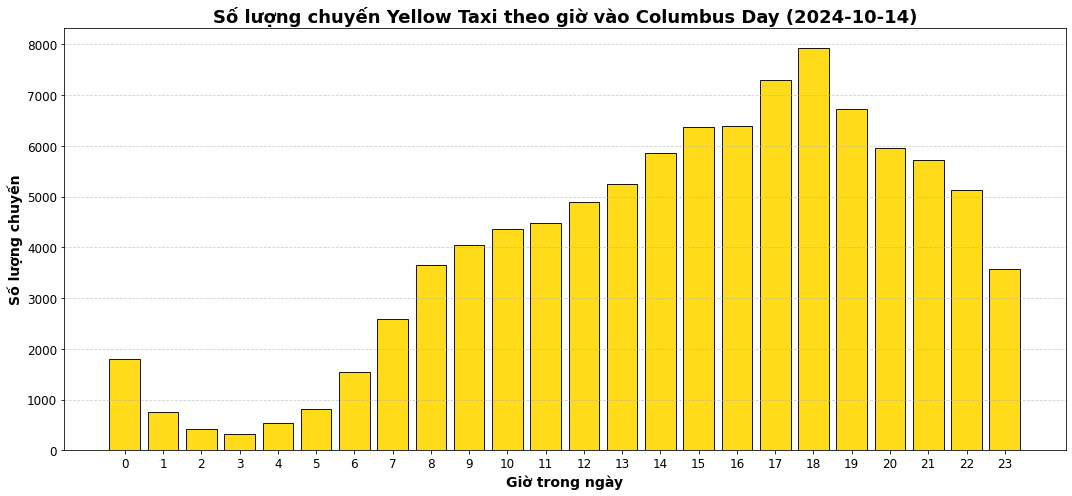


--- THỐNG KÊ CHI TIẾT CHO Columbus Day (2024-10-14) ---
Tổng số chuyến trong ngày: 96,408 chuyến
Giờ cao điểm: 18h (7,921 chuyến)


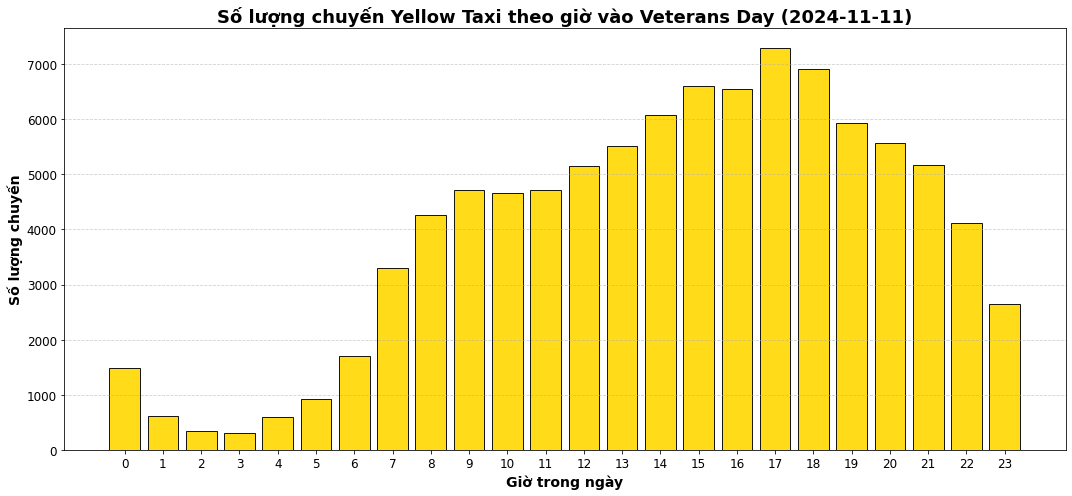


--- THỐNG KÊ CHI TIẾT CHO Veterans Day (2024-11-11) ---
Tổng số chuyến trong ngày: 95,130 chuyến
Giờ cao điểm: 17h (7,276 chuyến)


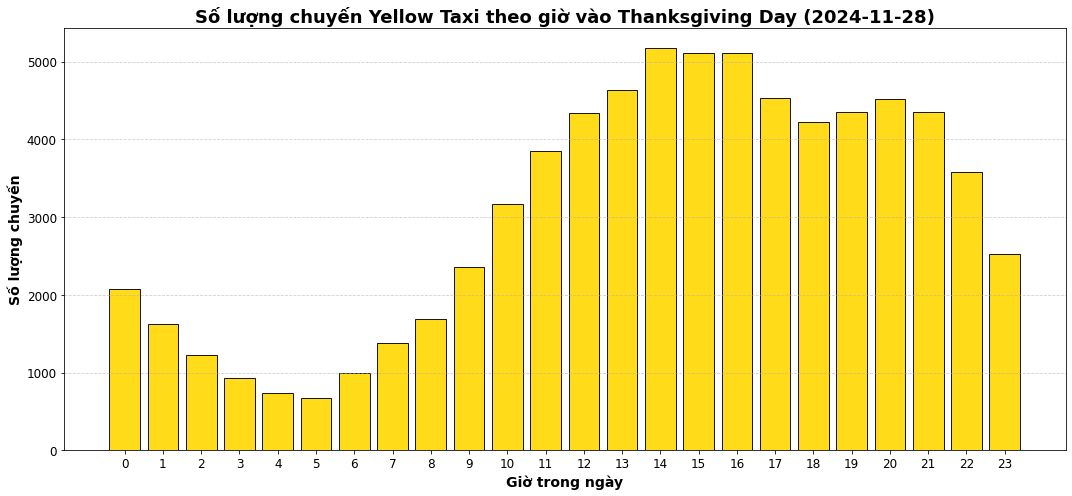


--- THỐNG KÊ CHI TIẾT CHO Thanksgiving Day (2024-11-28) ---
Tổng số chuyến trong ngày: 73,140 chuyến
Giờ cao điểm: 14h (5,169 chuyến)


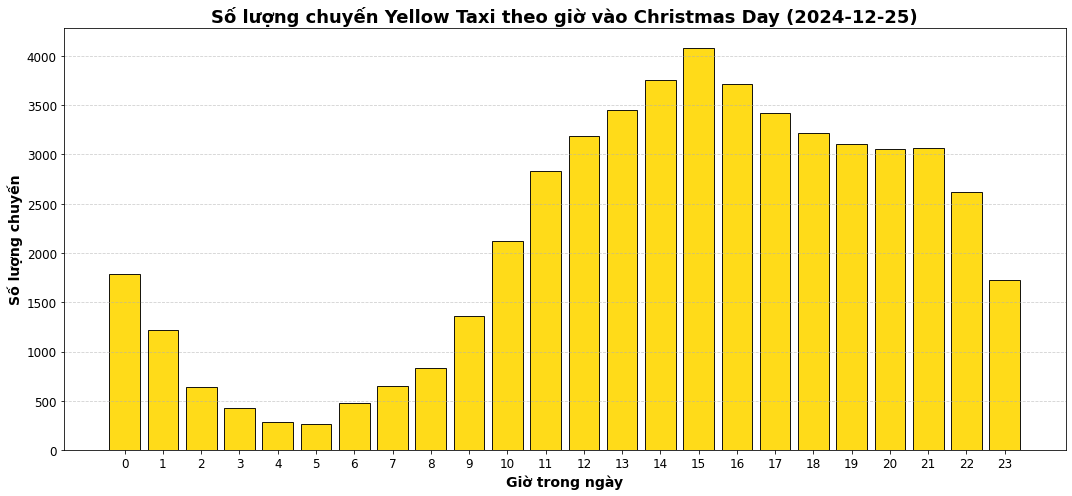


--- THỐNG KÊ CHI TIẾT CHO Christmas Day (2024-12-25) ---
Tổng số chuyến trong ngày: 51,316 chuyến
Giờ cao điểm: 15h (4,075 chuyến)


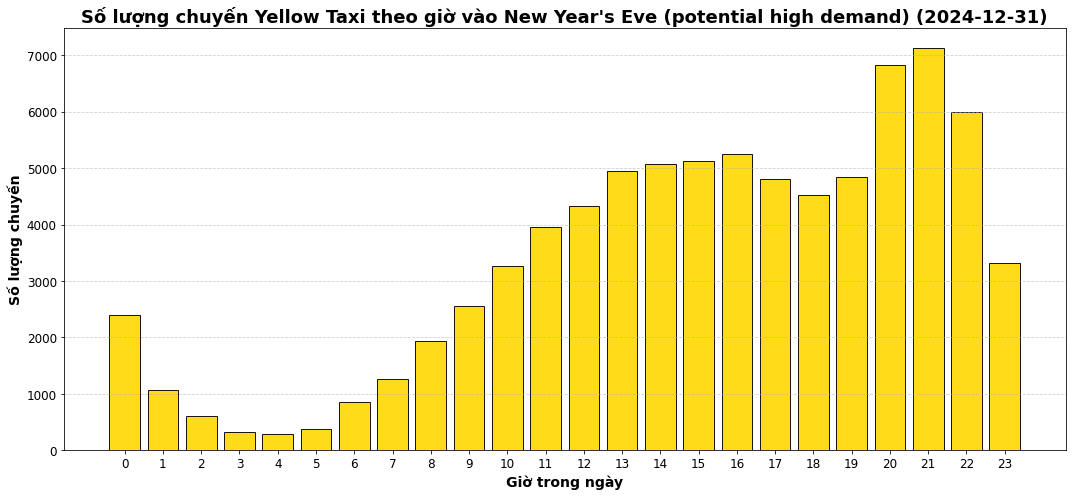


--- THỐNG KÊ CHI TIẾT CHO New Year's Eve (potential high demand) (2024-12-31) ---
Tổng số chuyến trong ngày: 81,046 chuyến
Giờ cao điểm: 21h (7,119 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT YELLOW TAXI ===


In [4]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour, date_format
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date

print("=== PHÂN TÍCH YELLOW TAXI: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")

# Đọc dữ liệu Parquet từ HDFS
df_yellow = spark.read.parquet("hdfs://master:9000/data/parquet/yellow_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu Yellow Taxi: {df_yellow.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_yellow_filtered = df_yellow.filter(
    (col("tpep_pickup_datetime").isNotNull()) &
    (col("tpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_yellow_filtered = df_yellow_filtered.withColumn("pickup_ts", to_timestamp(col("tpep_pickup_datetime"))) \
                                       .withColumn("dropoff_ts", to_timestamp(col("tpep_dropoff_datetime")))

df_yellow_filtered = df_yellow_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_yellow_filtered = df_yellow_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_yellow_filtered = df_yellow_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("trip_distance") > 0, (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_yellow_filtered = df_yellow_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_yellow_filtered = df_yellow_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("extra") >= 0) & (col("extra") < 100) &
    (col("mta_tax") >= 0) & (col("mta_tax") < 10) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("improvement_surcharge") >= 0) & (col("improvement_surcharge") < 10) &
    (col("total_amount") >= 0) & (col("total_amount") < 2000) &
    (col("congestion_surcharge").isNull() | (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))
)

print(f"Tổng số dòng sau khi lọc Yellow Taxi: {df_yellow_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_yellow = df_yellow_filtered.withColumn("pickup_ts", to_timestamp("tpep_pickup_datetime"))

# --- PHÂN TÍCH SỐ LƯỢNG CHUYẾN THEO GIỜ TRONG NGÀY LỄ ---

# Bước 1: Định nghĩa các ngày lễ
nyc_holidays_2024_map = {
    date(2024, 1, 1): "New Year's Day",
    date(2024, 1, 15): "Martin Luther King, Jr. Day",
    date(2024, 2, 19): "Presidents' Day",
    date(2024, 5, 27): "Memorial Day",
    date(2024, 6, 19): "Juneteenth",
    date(2024, 7, 4): "Independence Day",
    date(2024, 9, 2): "Labor Day",
    date(2024, 10, 14): "Columbus Day",
    date(2024, 11, 11): "Veterans Day",
    date(2024, 11, 28): "Thanksgiving Day",
    date(2024, 12, 25): "Christmas Day",
    date(2024, 12, 31): "New Year's Eve (potential high demand)"
}
nyc_holiday_dates = list(nyc_holidays_2024_map.keys())

# Bước 2: Thêm các cột cần thiết
df_yellow_with_holidays = df_cleaned_yellow.withColumn("pickup_date", to_date(col("pickup_ts"))) \
                                           .withColumn("hour", hour(col("pickup_ts")))

df_yellow_with_holidays = df_yellow_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holiday_dates), True).otherwise(False)
)

# Lọc các chuyến trong ngày lễ
df_holiday_trips_yellow = df_yellow_with_holidays.filter(col("is_holiday") == True)

print("\n=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (YELLOW TAXI) ===")
df_holiday_trips_yellow.select("tpep_pickup_datetime", "pickup_date", "hour", "PULocationID").show(5)

# Bước 3: Nhóm và đếm
df_yellow_holiday_hourly_counts = df_holiday_trips_yellow \
    .groupBy(date_format(col("pickup_date"), "yyyy-MM-dd").alias("holiday_date"), "hour") \
    .count() \
    .orderBy("holiday_date", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN YELLOW TAXI THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")
df_yellow_holiday_hourly_counts.show(df_yellow_holiday_hourly_counts.count(), False)

# Chuyển sang Pandas để vẽ
pdf_yellow_holiday_hourly = df_yellow_holiday_hourly_counts.toPandas()

# Vẽ biểu đồ cho từng ngày lễ
unique_holidays = pdf_yellow_holiday_hourly['holiday_date'].unique()

for holiday_date_str in unique_holidays:
    holiday_name = nyc_holidays_2024_map.get(date.fromisoformat(holiday_date_str), holiday_date_str)
    
    data_for_holiday = pdf_yellow_holiday_hourly[pdf_yellow_holiday_hourly['holiday_date'] == holiday_date_str].sort_values('hour')
    
    # --- BẮT ĐẦU PHẦN CODE ĐÃ THAY ĐỔI ---
    plt.figure(figsize=(15, 7)) # Tăng kích thước biểu đồ

    # Thay plt.plot bằng plt.bar
    plt.bar(data_for_holiday['hour'], data_for_holiday['count'], color='gold', alpha=0.9, edgecolor='black')
    
    # Tăng kích thước phông chữ
    plt.title(f'Số lượng chuyến Yellow Taxi theo giờ vào {holiday_name} ({holiday_date_str})', fontsize=18, fontweight='bold')
    plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
    plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
    plt.xticks(range(0, 24), fontsize=12) # Hiển thị tất cả các giờ
    plt.yticks(fontsize=12)
    
    plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.6)
    
    plt.ticklabel_format(style='plain', axis='y') # Đảm bảo không dùng ký hiệu khoa học
    
    plt.tight_layout()
    plt.show()
    # --- KẾT THÚC PHẦN CODE ĐÃ THAY ĐỔI ---

    print(f"\n--- THỐNG KÊ CHI TIẾT CHO {holiday_name} ({holiday_date_str}) ---")
    if not data_for_holiday.empty:
        total_trips_on_holiday = data_for_holiday['count'].sum()
        peak_hour_data = data_for_holiday.loc[data_for_holiday['count'].idxmax()]
        print(f"Tổng số chuyến trong ngày: {total_trips_on_holiday:,.0f} chuyến")
        print(f"Giờ cao điểm: {peak_hour_data['hour']:0.0f}h ({peak_hour_data['count']:,.0f} chuyến)")
    else:
        print("Không có dữ liệu chuyến đi nào cho ngày này.")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT YELLOW TAXI ===")

=== PHÂN TÍCH GREEN TAXI: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
Tổng số dòng ban đầu Green Taxi: 660218
Tổng số dòng sau khi lọc Green Taxi: 608805

=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (GREEN TAXI) ===
+--------------------+-----------+----+------------+
|lpep_pickup_datetime|pickup_date|hour|PULocationID|
+--------------------+-----------+----+------------+
| 2024-05-27 00:35:48| 2024-05-27|   0|         260|
| 2024-05-27 00:49:28| 2024-05-27|   0|         260|
| 2024-05-27 00:06:33| 2024-05-27|   0|          74|
| 2024-05-27 00:05:44| 2024-05-27|   0|          82|
| 2024-05-27 00:16:10| 2024-05-27|   0|         255|
+--------------------+-----------+----+------------+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN GREEN TAXI THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===
+------------+----+-----+
|holiday_date|hour|count|
+------------+----+-----+
|2024-01-01  |0   |80   |
|2024-01-01  |1   |89   |
|2024-01-01  |2   |65   |
|2024-01-01  |3   |33   |
|2024-01-01  |4   |22   |

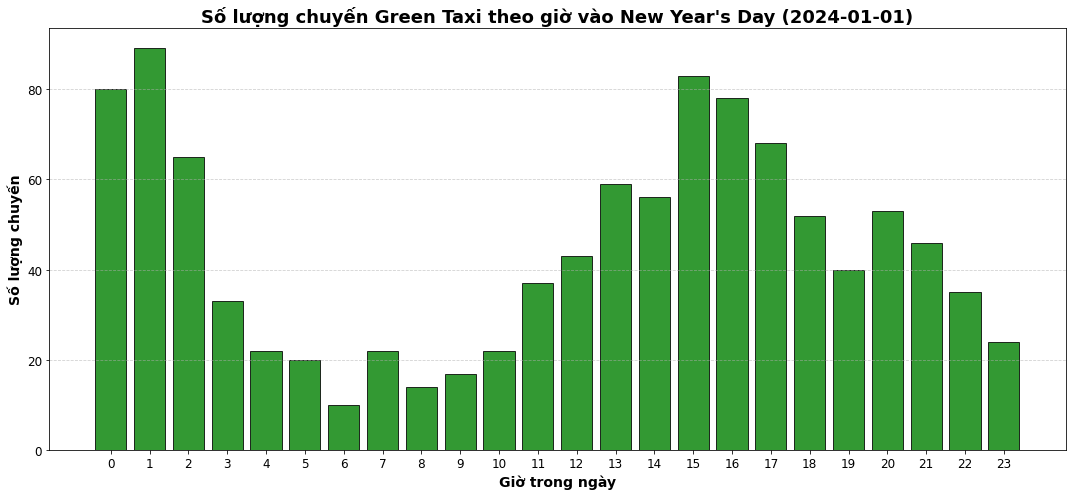


--- THỐNG KÊ CHI TIẾT CHO New Year's Day (2024-01-01) ---
Tổng số chuyến trong ngày: 1,068 chuyến
Giờ cao điểm: 1h (89 chuyến)


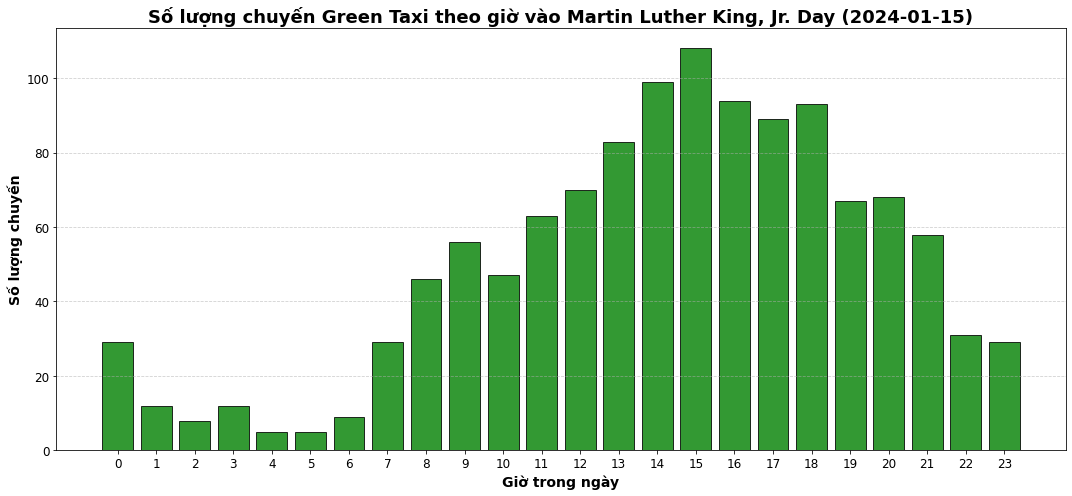


--- THỐNG KÊ CHI TIẾT CHO Martin Luther King, Jr. Day (2024-01-15) ---
Tổng số chuyến trong ngày: 1,210 chuyến
Giờ cao điểm: 15h (108 chuyến)


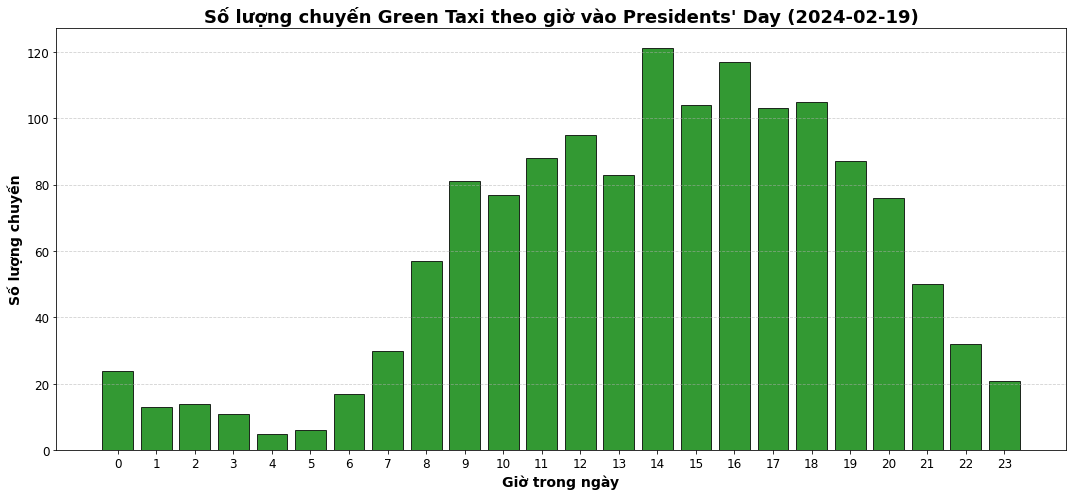


--- THỐNG KÊ CHI TIẾT CHO Presidents' Day (2024-02-19) ---
Tổng số chuyến trong ngày: 1,417 chuyến
Giờ cao điểm: 14h (121 chuyến)


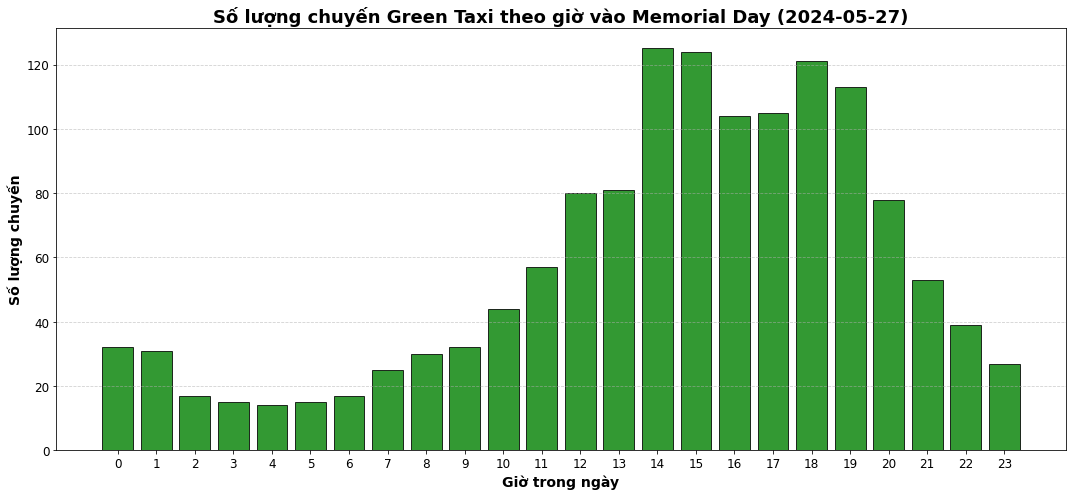


--- THỐNG KÊ CHI TIẾT CHO Memorial Day (2024-05-27) ---
Tổng số chuyến trong ngày: 1,379 chuyến
Giờ cao điểm: 14h (125 chuyến)


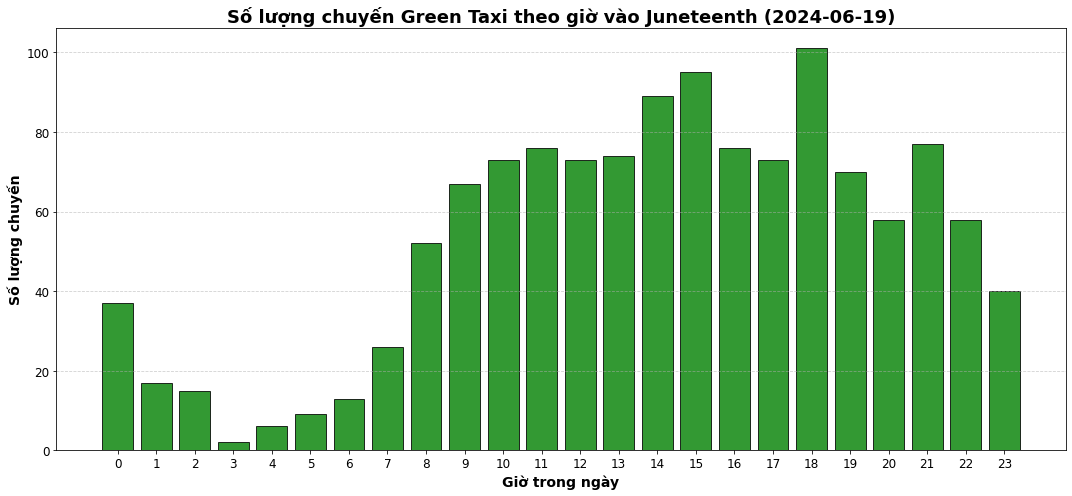


--- THỐNG KÊ CHI TIẾT CHO Juneteenth (2024-06-19) ---
Tổng số chuyến trong ngày: 1,277 chuyến
Giờ cao điểm: 18h (101 chuyến)


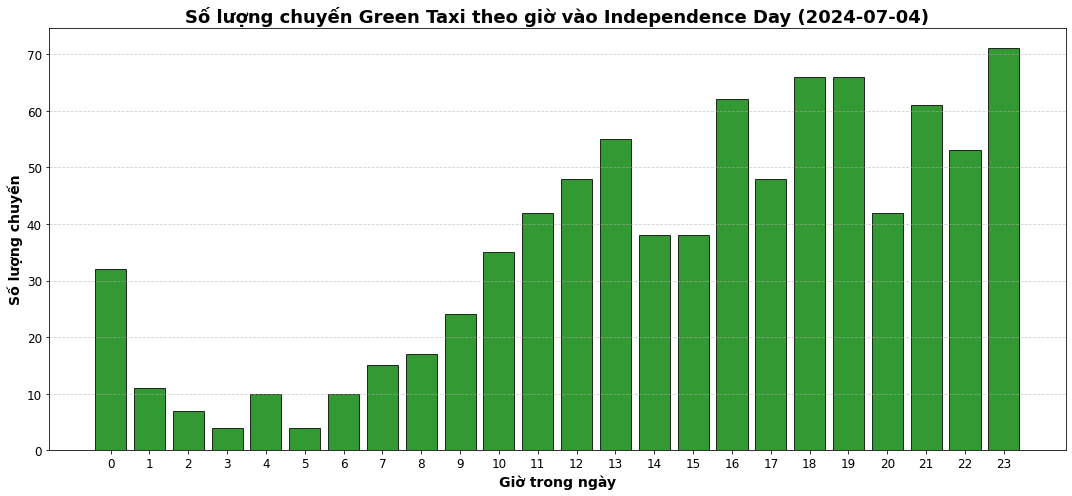


--- THỐNG KÊ CHI TIẾT CHO Independence Day (2024-07-04) ---
Tổng số chuyến trong ngày: 859 chuyến
Giờ cao điểm: 23h (71 chuyến)


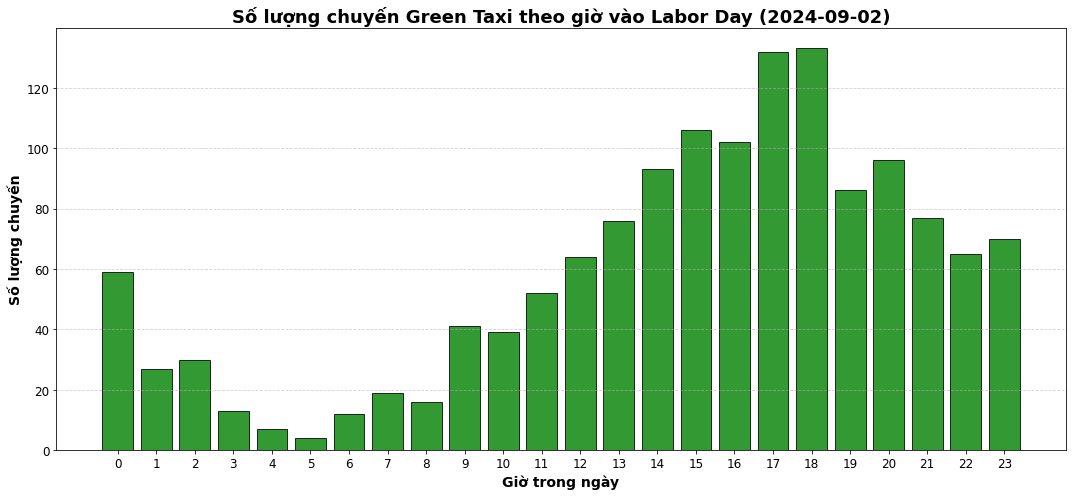


--- THỐNG KÊ CHI TIẾT CHO Labor Day (2024-09-02) ---
Tổng số chuyến trong ngày: 1,419 chuyến
Giờ cao điểm: 18h (133 chuyến)


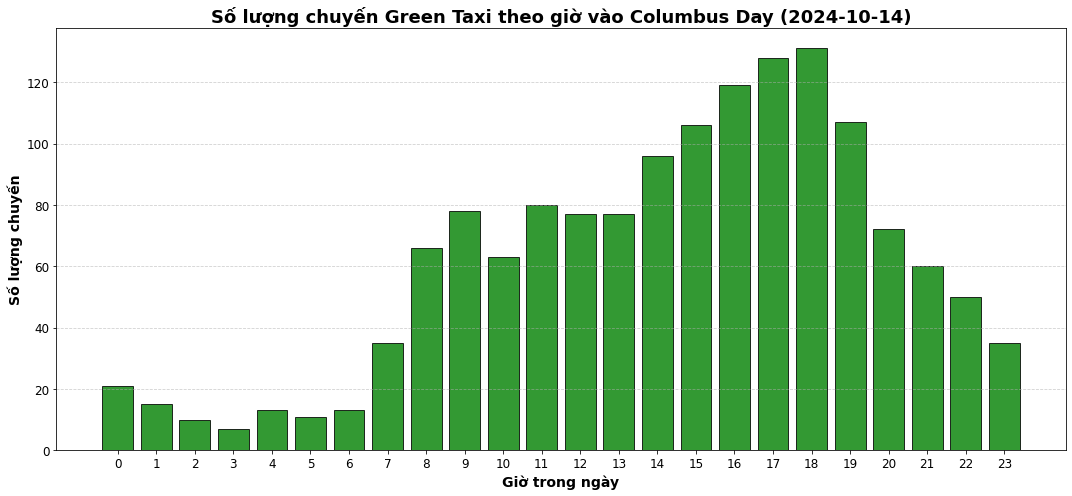


--- THỐNG KÊ CHI TIẾT CHO Columbus Day (2024-10-14) ---
Tổng số chuyến trong ngày: 1,470 chuyến
Giờ cao điểm: 18h (131 chuyến)


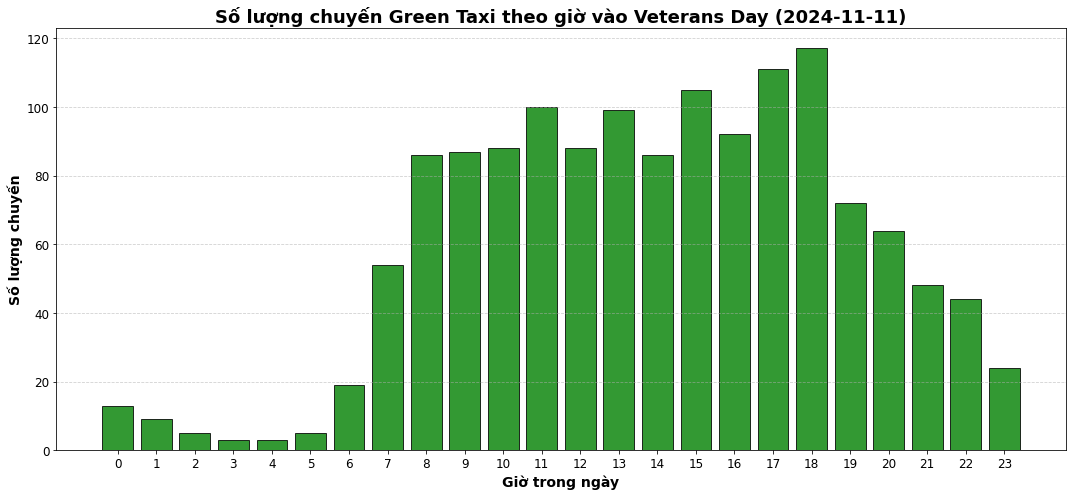


--- THỐNG KÊ CHI TIẾT CHO Veterans Day (2024-11-11) ---
Tổng số chuyến trong ngày: 1,422 chuyến
Giờ cao điểm: 18h (117 chuyến)


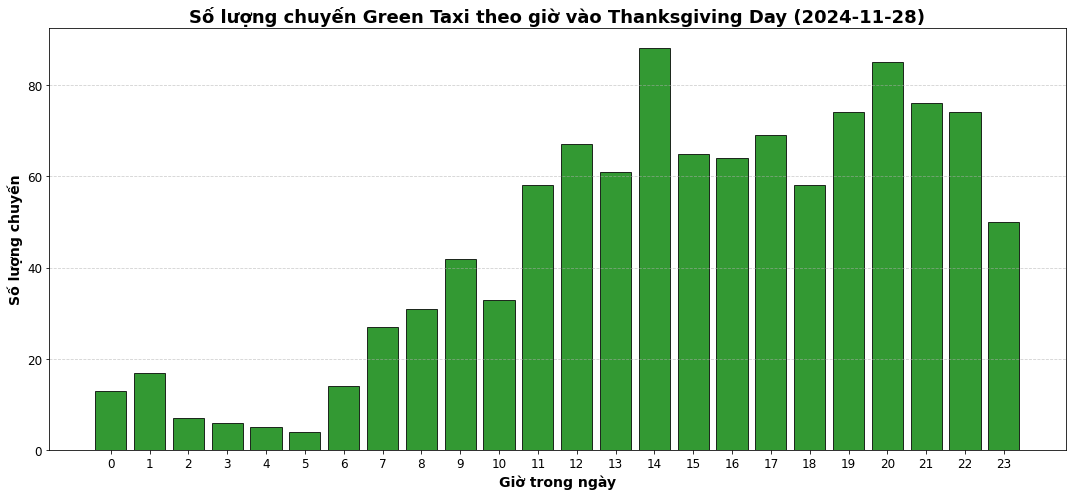


--- THỐNG KÊ CHI TIẾT CHO Thanksgiving Day (2024-11-28) ---
Tổng số chuyến trong ngày: 1,088 chuyến
Giờ cao điểm: 14h (88 chuyến)


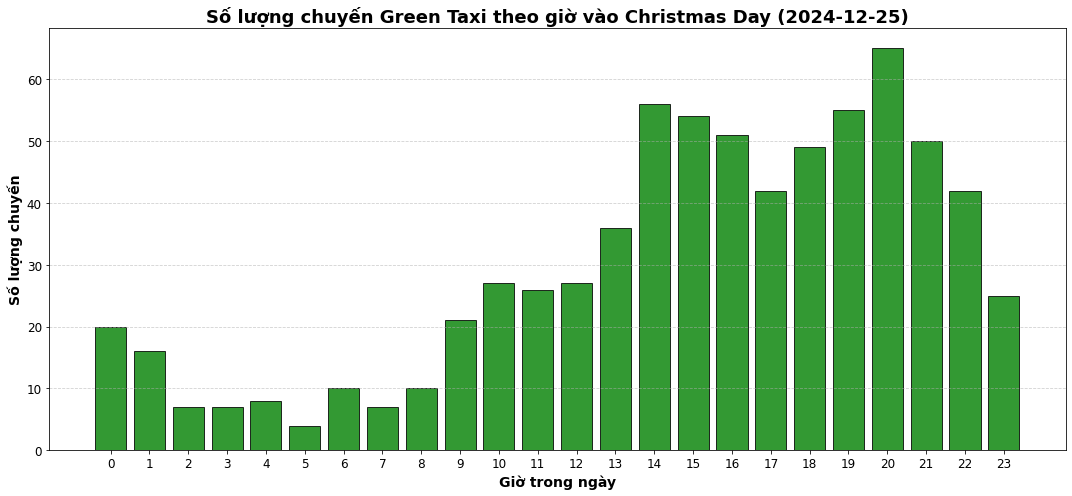


--- THỐNG KÊ CHI TIẾT CHO Christmas Day (2024-12-25) ---
Tổng số chuyến trong ngày: 715 chuyến
Giờ cao điểm: 20h (65 chuyến)


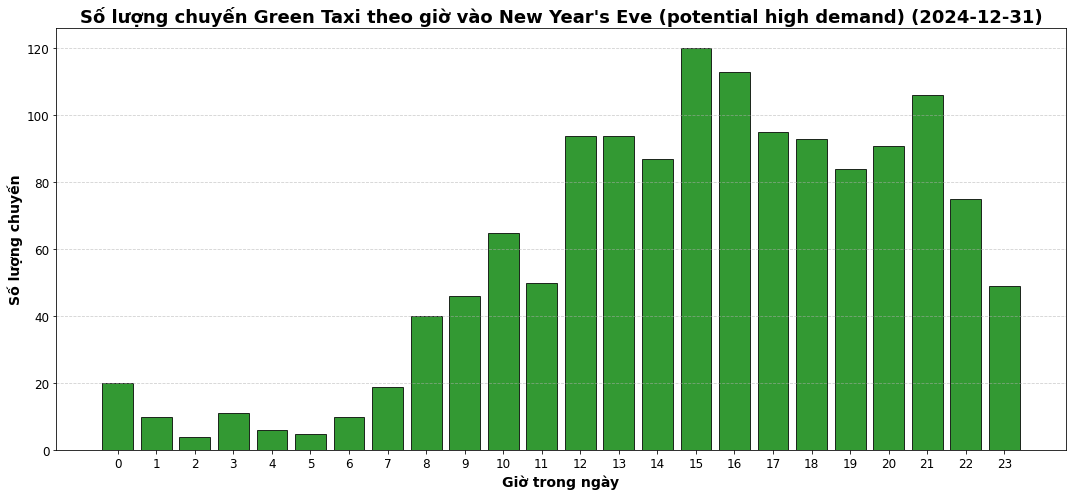


--- THỐNG KÊ CHI TIẾT CHO New Year's Eve (potential high demand) (2024-12-31) ---
Tổng số chuyến trong ngày: 1,387 chuyến
Giờ cao điểm: 15h (120 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT GREEN TAXI ===


In [5]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour, date_format
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date

print("=== PHÂN TÍCH GREEN TAXI: SỐ CHUYẾN THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")

# Đọc dữ liệu Parquet từ HDFS
df_green = spark.read.parquet("hdfs://master:9000/data/parquet/green_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu Green Taxi: {df_green.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_green_filtered = df_green.filter(
    (col("lpep_pickup_datetime").isNotNull()) &
    (col("lpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_green_filtered = df_green_filtered.withColumn("pickup_ts", to_timestamp(col("lpep_pickup_datetime"))) \
                                     .withColumn("dropoff_ts", to_timestamp(col("lpep_dropoff_datetime")))

df_green_filtered = df_green_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_green_filtered = df_green_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_green_filtered = df_green_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("trip_distance") > 0, (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_green_filtered = df_green_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_green_filtered = df_green_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("extra") >= 0) & (col("extra") < 100) &
    (col("mta_tax") >= 0) & (col("mta_tax") < 10) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("improvement_surcharge") >= 0) & (col("improvement_surcharge") < 10) &
    (col("total_amount") >= 0) & (col("total_amount") < 2000) &
    (col("congestion_surcharge").isNull() | (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))
)

print(f"Tổng số dòng sau khi lọc Green Taxi: {df_green_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_green = df_green_filtered.withColumn("pickup_ts", to_timestamp("lpep_pickup_datetime"))

# --- PHÂN TÍCH SỐ LƯỢNG CHUYẾN THEO GIỜ TRONG NGÀY LỄ ---

# Bước 1: Định nghĩa các ngày lễ
nyc_holidays_2024_map = {
    date(2024, 1, 1): "New Year's Day",
    date(2024, 1, 15): "Martin Luther King, Jr. Day",
    date(2024, 2, 19): "Presidents' Day",
    date(2024, 5, 27): "Memorial Day",
    date(2024, 6, 19): "Juneteenth",
    date(2024, 7, 4): "Independence Day",
    date(2024, 9, 2): "Labor Day",
    date(2024, 10, 14): "Columbus Day",
    date(2024, 11, 11): "Veterans Day",
    date(2024, 11, 28): "Thanksgiving Day",
    date(2024, 12, 25): "Christmas Day",
    date(2024, 12, 31): "New Year's Eve (potential high demand)"
}
nyc_holiday_dates = list(nyc_holidays_2024_map.keys())

# Bước 2: Thêm các cột cần thiết
df_green_with_holidays = df_cleaned_green.withColumn("pickup_date", to_date(col("pickup_ts"))) \
                                         .withColumn("hour", hour(col("pickup_ts")))

df_green_with_holidays = df_green_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holiday_dates), True).otherwise(False)
)

# Lọc các chuyến trong ngày lễ
df_holiday_trips_green = df_green_with_holidays.filter(col("is_holiday") == True)

print("\n=== DỮ LIỆU MẪU CỦA CÁC CHUYẾN TRONG NGÀY LỄ (GREEN TAXI) ===")
df_holiday_trips_green.select("lpep_pickup_datetime", "pickup_date", "hour", "PULocationID").show(5)

# Bước 3: Nhóm và đếm
df_green_holiday_hourly_counts = df_holiday_trips_green \
    .groupBy(date_format(col("pickup_date"), "yyyy-MM-dd").alias("holiday_date"), "hour") \
    .count() \
    .orderBy("holiday_date", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN GREEN TAXI THEO GIỜ TRONG TỪNG NGÀY ĐẶC BIỆT ===")
df_green_holiday_hourly_counts.show(df_green_holiday_hourly_counts.count(), False)

# Chuyển sang Pandas để vẽ
pdf_green_holiday_hourly = df_green_holiday_hourly_counts.toPandas()

# Vẽ biểu đồ cho từng ngày lễ
unique_holidays = pdf_green_holiday_hourly['holiday_date'].unique()

for holiday_date_str in unique_holidays:
    holiday_name = nyc_holidays_2024_map.get(date.fromisoformat(holiday_date_str), holiday_date_str)
    
    data_for_holiday = pdf_green_holiday_hourly[pdf_green_holiday_hourly['holiday_date'] == holiday_date_str].sort_values('hour')
    
    # --- BẮT ĐẦU PHẦN CODE ĐÃ THAY ĐỔI ---
    plt.figure(figsize=(15, 7)) # Tăng kích thước biểu đồ

    # Thay plt.plot bằng plt.bar
    plt.bar(data_for_holiday['hour'], data_for_holiday['count'], color='green', alpha=0.8, edgecolor='black')
    
    # Tăng kích thước phông chữ
    plt.title(f'Số lượng chuyến Green Taxi theo giờ vào {holiday_name} ({holiday_date_str})', fontsize=18, fontweight='bold')
    plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
    plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
    plt.xticks(range(0, 24), fontsize=12) # Hiển thị tất cả các giờ
    plt.yticks(fontsize=12)
    
    plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.6)
    
    plt.ticklabel_format(style='plain', axis='y') # Đảm bảo không dùng ký hiệu khoa học
    
    plt.tight_layout()
    plt.show()
    # --- KẾT THÚC PHẦN CODE ĐÃ THAY ĐỔI ---

    print(f"\n--- THỐNG KÊ CHI TIẾT CHO {holiday_name} ({holiday_date_str}) ---")
    if not data_for_holiday.empty:
        total_trips_on_holiday = data_for_holiday['count'].sum()
        peak_hour_data = data_for_holiday.loc[data_for_holiday['count'].idxmax()]
        print(f"Tổng số chuyến trong ngày: {total_trips_on_holiday:,.0f} chuyến")
        print(f"Giờ cao điểm: {peak_hour_data['hour']:0.0f}h ({peak_hour_data['count']:,.0f} chuyến)")
    else:
        print("Không có dữ liệu chuyến đi nào cho ngày này.")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT GREEN TAXI ===")

=== PHÂN TÍCH HIGH-VOLUME FHVHV: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===
Tổng số dòng ban đầu FHVHV: 239470448
Tổng số dòng sau khi lọc FHVHV: 229319569

=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (FHVHV) ===
+-------------------+-----------+----------+----+
|    pickup_datetime|pickup_date|is_holiday|hour|
+-------------------+-----------+----------+----+
|2024-01-01 00:28:08| 2024-01-01|      true|   0|
|2024-01-01 00:12:53| 2024-01-01|      true|   0|
|2024-01-01 00:23:05| 2024-01-01|      true|   0|
|2024-01-01 00:41:04| 2024-01-01|      true|   0|
|2024-01-01 00:57:21| 2024-01-01|      true|   0|
+-------------------+-----------+----------+----+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (FHVHV) ===
+----------+----+--------+
|is_holiday|hour|   count|
+----------+----+--------+
|     false|   0| 8122000|
|     false|   1| 5651694|
|     false|   2| 4032767|
|     false|   3| 3255638|
|     false|   4| 3438083|
|     false|   5| 4060582|
|     false|   6| 

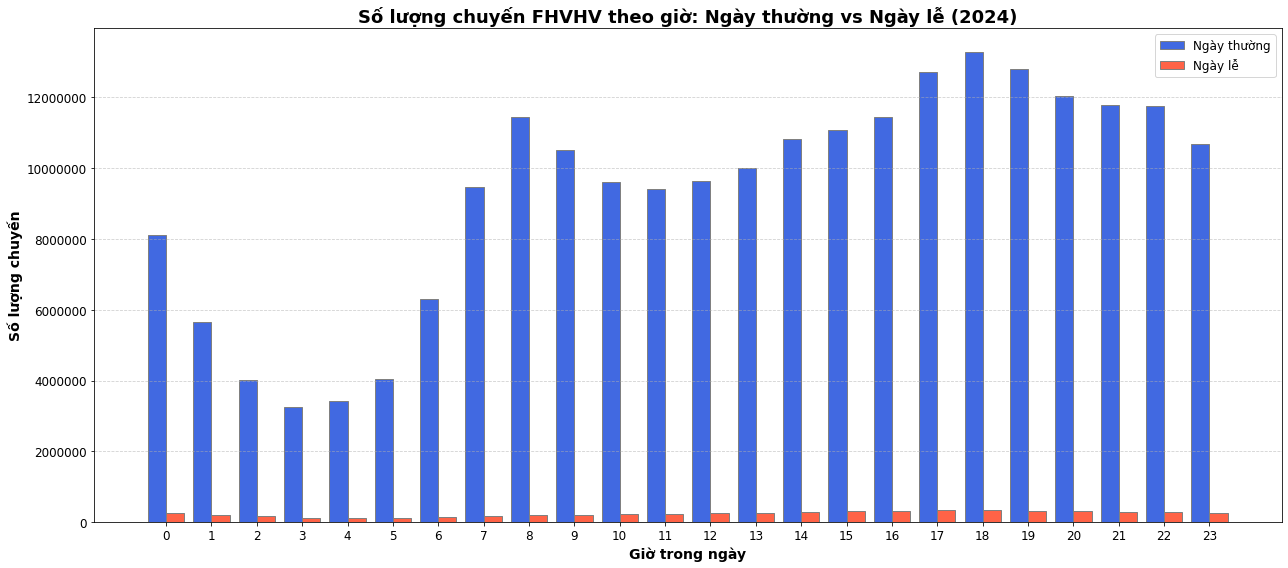


--- THỐNG KÊ CHI TIẾT NGÀY LỄ (FHVHV) ---
Tổng số chuyến trung bình vào ngày lễ: 246,378 chuyến/giờ
Giờ cao điểm ngày lễ: 18h (348,189 chuyến)

--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (FHVHV) ---
Tổng số chuyến trung bình vào ngày thường: 9,308,604 chuyến/giờ
Giờ cao điểm ngày thường: 18h (13,284,033 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT FHVHV ===


In [6]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
import numpy as np

print("=== PHÂN TÍCH HIGH-VOLUME FHVHV: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===")

# Đọc dữ liệu Parquet từ HDFS
df = spark.read.parquet("hdfs://master:9000/data/parquet/fhvhv_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu FHVHV: {df.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_filtered = df.filter(
    (col("pickup_datetime").isNotNull()) &
    (col("dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_filtered = df_filtered.withColumn("pickup_ts", to_timestamp(col("pickup_datetime"))) \
                          .withColumn("dropoff_ts", to_timestamp(col("dropoff_datetime")))

df_filtered = df_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_filtered = df_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_filtered = df_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("calculated_trip_time_seconds") > 0, (col("trip_miles") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_filtered = df_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_miles") >= 0.1) & (col("trip_miles") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_filtered = df_filtered.filter(
    (col("base_passenger_fare") >= 0) & (col("base_passenger_fare") < 1000) &
    (col("tolls") >= 0) & (col("tolls") < 200) &
    (col("bcf") >= 0) & (col("bcf") < 100) &
    (col("sales_tax") >= 0) & (col("sales_tax") < 100) &
    (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20) &
    (col("airport_fee") >= 0) & (col("airport_fee") < 50) &
    (col("tips") >= 0) & (col("tips") < 300) &
    (col("driver_pay") >= 0) & (col("driver_pay") < 1000)
)

print(f"Tổng số dòng sau khi lọc FHVHV: {df_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_fhvhv = df_filtered.withColumn("pickup_ts", to_timestamp("pickup_datetime"))

# --- PHÂN TÍCH BỔ SUNG: NGÀY LỄ (FHVHV) ---

# Bước 1: Định nghĩa các ngày lễ ở NYC năm 2024
nyc_holidays_2024 = [
    date(2024, 1, 1), date(2024, 1, 15), date(2024, 2, 19),
    date(2024, 5, 27), date(2024, 6, 19), date(2024, 7, 4),
    date(2024, 9, 2), date(2024, 10, 14), date(2024, 11, 11),
    date(2024, 11, 28), date(2024, 12, 25)
]

# Bước 2: Thêm cột `is_holiday` và `hour`
df_fhvhv_with_holidays = df_cleaned_fhvhv.withColumn("pickup_date", to_date(col("pickup_ts")))
df_fhvhv_with_holidays = df_fhvhv_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holidays_2024), True).otherwise(False)
).withColumn("hour", hour(col("pickup_ts")))

print("\n=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (FHVHV) ===")
df_fhvhv_with_holidays.select("pickup_datetime", "pickup_date", "is_holiday", "hour").show(5)

# Bước 3: Phân tích số lượng chuyến theo giờ
df_fhvhv_holiday_vs_normal = df_fhvhv_with_holidays.groupBy("is_holiday", "hour").count().orderBy("is_holiday", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (FHVHV) ===")
df_fhvhv_holiday_vs_normal.show()

# --- BẮT ĐẦU PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---
# Chuyển sang Pandas để vẽ biểu đồ
pdf_fhvhv_holiday_vs_normal = df_fhvhv_holiday_vs_normal.toPandas()

# Tạo DataFrame đầy đủ 24 giờ để đảm bảo không thiếu giờ nào
hours_df = pd.DataFrame({'hour': range(24)})

# Tách và chuẩn bị dữ liệu
holiday_data = pdf_fhvhv_holiday_vs_normal[pdf_fhvhv_holiday_vs_normal['is_holiday'] == True]
normal_data = pdf_fhvhv_holiday_vs_normal[pdf_fhvhv_holiday_vs_normal['is_holiday'] == False]

# Merge với DataFrame giờ đầy đủ, điền 0 cho các giờ bị thiếu
holiday_counts = pd.merge(hours_df, holiday_data, on='hour', how='left').fillna(0)
normal_counts = pd.merge(hours_df, normal_data, on='hour', how='left').fillna(0)

# Vẽ biểu đồ cột nhóm
plt.figure(figsize=(18, 8))
bar_width = 0.4
r1 = np.arange(len(normal_counts['hour']))
r2 = [x + bar_width for x in r1]

plt.bar(r1, normal_counts['count'], color='royalblue', width=bar_width, edgecolor='grey', label='Ngày thường')
plt.bar(r2, holiday_counts['count'], color='tomato', width=bar_width, edgecolor='grey', label='Ngày lễ')

# Tăng kích thước phông chữ và định dạng
plt.title('Số lượng chuyến FHVHV theo giờ: Ngày thường vs Ngày lễ (2024)', fontsize=18, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(normal_counts['hour']))], normal_counts['hour'], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y') # Hiển thị số đầy đủ
plt.tight_layout()
plt.show()
# --- KẾT THÚC PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---

print("\n--- THỐNG KÊ CHI TIẾT NGÀY LỄ (FHVHV) ---")
if not holiday_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày lễ: {holiday_counts['count'].mean():,.0f} chuyến/giờ")
    fhvhv_holiday_peak_hour = holiday_counts.loc[holiday_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày lễ: {fhvhv_holiday_peak_hour['hour']:0.0f}h ({fhvhv_holiday_peak_hour['count']:,.0f} chuyến)")

print("\n--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (FHVHV) ---")
if not normal_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày thường: {normal_counts['count'].mean():,.0f} chuyến/giờ")
    fhvhv_normal_peak_hour = normal_counts.loc[normal_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày thường: {fhvhv_normal_peak_hour['hour']:0.0f}h ({fhvhv_normal_peak_hour['count']:,.0f} chuyến)")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT FHVHV ===")


=== PHÂN TÍCH YELLOW TAXI: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===
Tổng số dòng ban đầu Yellow Taxi: 41169720
Tổng số dòng sau khi lọc Yellow Taxi: 39107100

=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (YELLOW TAXI) ===
+--------------------+-----------+----------+----+
|tpep_pickup_datetime|pickup_date|is_holiday|hour|
+--------------------+-----------+----------+----+
| 2024-01-01 00:57:55| 2024-01-01|      true|   0|
| 2024-01-01 00:03:00| 2024-01-01|      true|   0|
| 2024-01-01 00:17:06| 2024-01-01|      true|   0|
| 2024-01-01 00:36:38| 2024-01-01|      true|   0|
| 2024-01-01 00:46:51| 2024-01-01|      true|   0|
+--------------------+-----------+----------+----+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (YELLOW TAXI) ===
+----------+----+-------+
|is_holiday|hour|  count|
+----------+----+-------+
|     false|   0|1094677|
|     false|   1| 705766|
|     false|   2| 456791|
|     false|   3| 296109|
|     false|   4| 213634|
|     false|   5| 236431|
| 

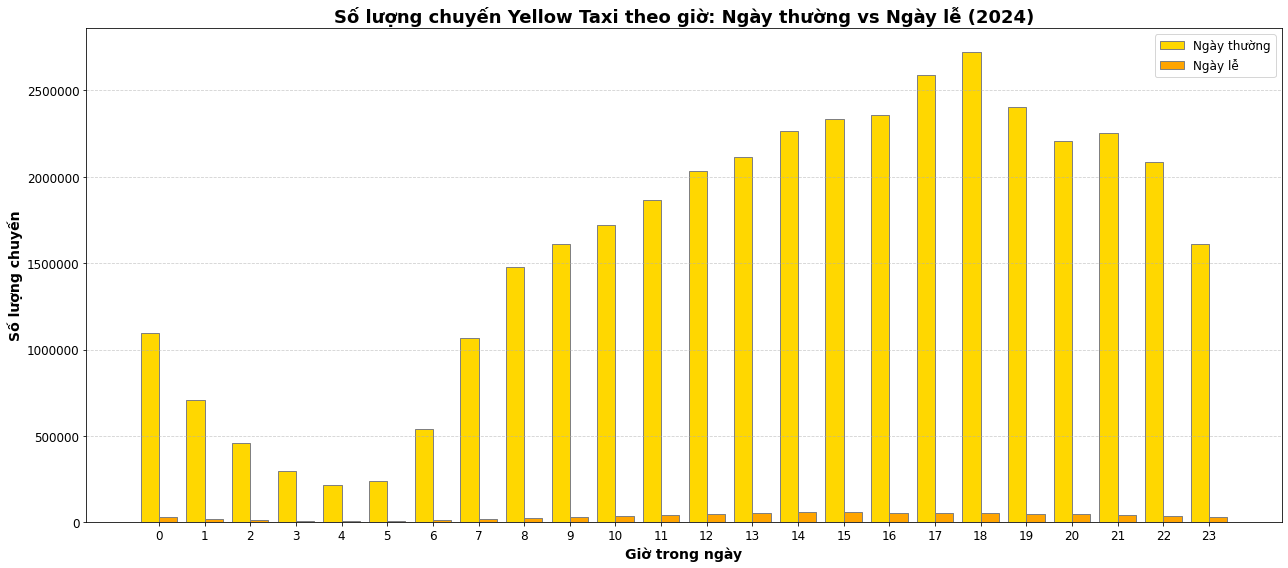


--- THỐNG KÊ CHI TIẾT NGÀY LỄ (YELLOW TAXI) ---
Tổng số chuyến trung bình vào ngày lễ: 34,913 chuyến/giờ
Giờ cao điểm ngày lễ: 14h (58,732 chuyến)

--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (YELLOW TAXI) ---
Tổng số chuyến trung bình vào ngày thường: 1,594,550 chuyến/giờ
Giờ cao điểm ngày thường: 18h (2,723,367 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT YELLOW TAXI ===


In [7]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
import numpy as np

print("=== PHÂN TÍCH YELLOW TAXI: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===")

# Đọc dữ liệu Parquet từ HDFS cho Yellow Taxi
df_yellow = spark.read.parquet("hdfs://master:9000/data/parquet/yellow_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu Yellow Taxi: {df_yellow.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_yellow_filtered = df_yellow.filter(
    (col("tpep_pickup_datetime").isNotNull()) &
    (col("tpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_yellow_filtered = df_yellow_filtered.withColumn("pickup_ts", to_timestamp(col("tpep_pickup_datetime"))) \
                                        .withColumn("dropoff_ts", to_timestamp(col("tpep_dropoff_datetime")))

df_yellow_filtered = df_yellow_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_yellow_filtered = df_yellow_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_yellow_filtered = df_yellow_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("trip_distance") > 0, (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_yellow_filtered = df_yellow_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_yellow_filtered = df_yellow_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("extra") >= 0) & (col("extra") < 100) &
    (col("mta_tax") >= 0) & (col("mta_tax") < 10) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("improvement_surcharge") >= 0) & (col("improvement_surcharge") < 10) &
    (col("total_amount") >= 0) & (col("total_amount") < 2000) &
    (col("congestion_surcharge").isNull() | (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))
)

print(f"Tổng số dòng sau khi lọc Yellow Taxi: {df_yellow_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_yellow = df_yellow_filtered.withColumn("pickup_ts", to_timestamp("tpep_pickup_datetime"))

# --- PHÂN TÍCH BỔ SUNG: NGÀY LỄ (YELLOW TAXI) ---

# Bước 1: Định nghĩa các ngày lễ ở NYC năm 2024
nyc_holidays_2024 = [
    date(2024, 1, 1), date(2024, 1, 15), date(2024, 2, 19),
    date(2024, 5, 27), date(2024, 6, 19), date(2024, 7, 4),
    date(2024, 9, 2), date(2024, 10, 14), date(2024, 11, 11),
    date(2024, 11, 28), date(2024, 12, 25)
]

# Bước 2: Thêm cột `is_holiday` và `hour`
df_yellow_with_holidays = df_cleaned_yellow.withColumn("pickup_date", to_date(col("pickup_ts")))
df_yellow_with_holidays = df_yellow_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holidays_2024), True).otherwise(False)
).withColumn("hour", hour(col("pickup_ts")))

print("\n=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (YELLOW TAXI) ===")
df_yellow_with_holidays.select("tpep_pickup_datetime", "pickup_date", "is_holiday", "hour").show(5)

# Bước 3: Phân tích số lượng chuyến theo giờ
df_yellow_holiday_vs_normal = df_yellow_with_holidays.groupBy("is_holiday", "hour").count().orderBy("is_holiday", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (YELLOW TAXI) ===")
df_yellow_holiday_vs_normal.show()

# --- BẮT ĐẦU PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---
# Chuyển sang Pandas để vẽ biểu đồ
pdf_yellow_holiday_vs_normal = df_yellow_holiday_vs_normal.toPandas()

# Tạo DataFrame đầy đủ 24 giờ để đảm bảo không thiếu giờ nào
hours_df = pd.DataFrame({'hour': range(24)})

# Tách và chuẩn bị dữ liệu
holiday_data = pdf_yellow_holiday_vs_normal[pdf_yellow_holiday_vs_normal['is_holiday'] == True]
normal_data = pdf_yellow_holiday_vs_normal[pdf_yellow_holiday_vs_normal['is_holiday'] == False]

# Merge với DataFrame giờ đầy đủ, điền 0 cho các giờ bị thiếu
holiday_counts = pd.merge(hours_df, holiday_data, on='hour', how='left').fillna(0)
normal_counts = pd.merge(hours_df, normal_data, on='hour', how='left').fillna(0)

# Vẽ biểu đồ cột nhóm
plt.figure(figsize=(18, 8))
bar_width = 0.4
r1 = np.arange(len(normal_counts['hour']))
r2 = [x + bar_width for x in r1]

plt.bar(r1, normal_counts['count'], color='gold', width=bar_width, edgecolor='grey', label='Ngày thường')
plt.bar(r2, holiday_counts['count'], color='orange', width=bar_width, edgecolor='grey', label='Ngày lễ')

# Tăng kích thước phông chữ và định dạng
plt.title('Số lượng chuyến Yellow Taxi theo giờ: Ngày thường vs Ngày lễ (2024)', fontsize=18, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(normal_counts['hour']))], normal_counts['hour'], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y') # Hiển thị số đầy đủ
plt.tight_layout()
plt.show()
# --- KẾT THÚC PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---

print("\n--- THỐNG KÊ CHI TIẾT NGÀY LỄ (YELLOW TAXI) ---")
if not holiday_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày lễ: {holiday_counts['count'].mean():,.0f} chuyến/giờ")
    yellow_holiday_peak_hour = holiday_counts.loc[holiday_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày lễ: {yellow_holiday_peak_hour['hour']:0.0f}h ({yellow_holiday_peak_hour['count']:,.0f} chuyến)")

print("\n--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (YELLOW TAXI) ---")
if not normal_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày thường: {normal_counts['count'].mean():,.0f} chuyến/giờ")
    yellow_normal_peak_hour = normal_counts.loc[normal_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày thường: {yellow_normal_peak_hour['hour']:0.0f}h ({yellow_normal_peak_hour['count']:,.0f} chuyến)")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT YELLOW TAXI ===")


=== PHÂN TÍCH GREEN TAXI: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===
Tổng số dòng ban đầu Green Taxi: 660218
Tổng số dòng sau khi lọc Green Taxi: 608805

=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (GREEN TAXI) ===
+--------------------+-----------+----------+----+
|lpep_pickup_datetime|pickup_date|is_holiday|hour|
+--------------------+-----------+----------+----+
| 2024-05-01 00:07:08| 2024-05-01|     false|   0|
| 2024-05-01 00:30:48| 2024-05-01|     false|   0|
| 2024-05-01 00:34:13| 2024-05-01|     false|   0|
| 2024-05-01 00:58:01| 2024-05-01|     false|   0|
| 2024-05-01 00:11:45| 2024-05-01|     false|   0|
+--------------------+-----------+----------+----+
only showing top 5 rows


=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (GREEN TAXI) ===
+----------+----+-----+
|is_holiday|hour|count|
+----------+----+-----+
|     false|   0|10280|
|     false|   1| 7077|
|     false|   2| 4965|
|     false|   3| 3700|
|     false|   4| 2991|
|     false|   5| 3044|
|     false|   6| 9046|
|    

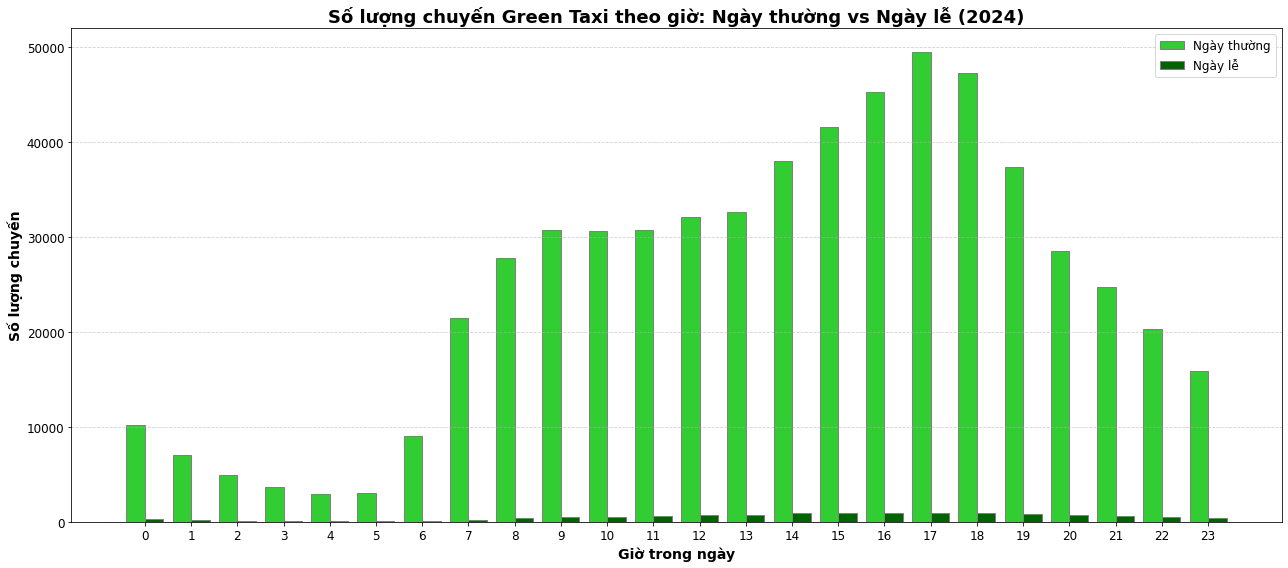


--- THỐNG KÊ CHI TIẾT NGÀY LỄ (GREEN TAXI) ---
Tổng số chuyến trung bình vào ngày lễ: 555 chuyến/giờ
Giờ cao điểm ngày lễ: 18h (1,026 chuyến)

--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (GREEN TAXI) ---
Tổng số chuyến trung bình vào ngày thường: 24,812 chuyến/giờ
Giờ cao điểm ngày thường: 17h (49,484 chuyến)

=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT GREEN TAXI ===


In [8]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, to_date, when, hour
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
import numpy as np

print("=== PHÂN TÍCH GREEN TAXI: NGÀY ĐẶC BIỆT (BIỂU ĐỒ CỘT) ===")

# Đọc dữ liệu Parquet từ HDFS cho Green Taxi
df_green = spark.read.parquet("hdfs://master:9000/data/parquet/green_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu Green Taxi: {df_green.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_green_filtered = df_green.filter(
    (col("lpep_pickup_datetime").isNotNull()) &
    (col("lpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull())
)

df_green_filtered = df_green_filtered.withColumn("pickup_ts", to_timestamp(col("lpep_pickup_datetime"))) \
                                      .withColumn("dropoff_ts", to_timestamp(col("lpep_dropoff_datetime")))

df_green_filtered = df_green_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_green_filtered = df_green_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)

df_green_filtered = df_green_filtered.withColumn(
    "calculated_average_speed_mph",
    when(col("trip_distance") > 0, (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600).otherwise(0)
)

df_green_filtered = df_green_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

df_green_filtered = df_green_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("extra") >= 0) & (col("extra") < 100) &
    (col("mta_tax") >= 0) & (col("mta_tax") < 10) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("improvement_surcharge") >= 0) & (col("improvement_surcharge") < 10) &
    (col("total_amount") >= 0) & (col("total_amount") < 2000) &
    (col("congestion_surcharge").isNull() | (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))
)

print(f"Tổng số dòng sau khi lọc Green Taxi: {df_green_filtered.count()}")

# SỬ DỤNG DỮ LIỆU ĐÃ LỌC CHO PHÂN TÍCH NGÀY ĐẶC BIỆT
df_cleaned_green = df_green_filtered.withColumn("pickup_ts", to_timestamp("lpep_pickup_datetime"))

# --- PHÂN TÍCH BỔ SUNG: NGÀY LỄ (GREEN TAXI) ---

# Bước 1: Định nghĩa các ngày lễ ở NYC năm 2024
nyc_holidays_2024 = [
    date(2024, 1, 1), date(2024, 1, 15), date(2024, 2, 19),
    date(2024, 5, 27), date(2024, 6, 19), date(2024, 7, 4),
    date(2024, 9, 2), date(2024, 10, 14), date(2024, 11, 11),
    date(2024, 11, 28), date(2024, 12, 25)
]

# Bước 2: Thêm cột `is_holiday` và `hour`
df_green_with_holidays = df_cleaned_green.withColumn("pickup_date", to_date(col("pickup_ts")))
df_green_with_holidays = df_green_with_holidays.withColumn(
    "is_holiday",
    when(col("pickup_date").isin(nyc_holidays_2024), True).otherwise(False)
).withColumn("hour", hour(col("pickup_ts")))

print("\n=== DỮ LIỆU MẪU VỚI CỘT 'IS_HOLIDAY' (GREEN TAXI) ===")
df_green_with_holidays.select("lpep_pickup_datetime", "pickup_date", "is_holiday", "hour").show(5)

# Bước 3: Phân tích số lượng chuyến theo giờ
df_green_holiday_vs_normal = df_green_with_holidays.groupBy("is_holiday", "hour").count().orderBy("is_holiday", "hour")

print("\n=== SỐ LƯỢNG CHUYẾN THEO GIỜ VÀO NGÀY LỄ VS NGÀY THƯỜNG (GREEN TAXI) ===")
df_green_holiday_vs_normal.show()

# --- BẮT ĐẦU PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---
# Chuyển sang Pandas để vẽ biểu đồ
pdf_green_holiday_vs_normal = df_green_holiday_vs_normal.toPandas()

# Tạo DataFrame đầy đủ 24 giờ để đảm bảo không thiếu giờ nào
hours_df = pd.DataFrame({'hour': range(24)})

# Tách và chuẩn bị dữ liệu
holiday_data = pdf_green_holiday_vs_normal[pdf_green_holiday_vs_normal['is_holiday'] == True]
normal_data = pdf_green_holiday_vs_normal[pdf_green_holiday_vs_normal['is_holiday'] == False]

# Merge với DataFrame giờ đầy đủ, điền 0 cho các giờ bị thiếu
holiday_counts = pd.merge(hours_df, holiday_data, on='hour', how='left').fillna(0)
normal_counts = pd.merge(hours_df, normal_data, on='hour', how='left').fillna(0)

# Vẽ biểu đồ cột nhóm
plt.figure(figsize=(18, 8))
bar_width = 0.4
r1 = np.arange(len(normal_counts['hour']))
r2 = [x + bar_width for x in r1]

plt.bar(r1, normal_counts['count'], color='limegreen', width=bar_width, edgecolor='grey', label='Ngày thường')
plt.bar(r2, holiday_counts['count'], color='darkgreen', width=bar_width, edgecolor='grey', label='Ngày lễ')

# Tăng kích thước phông chữ và định dạng
plt.title('Số lượng chuyến Green Taxi theo giờ: Ngày thường vs Ngày lễ (2024)', fontsize=18, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng chuyến', fontsize=14, fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(normal_counts['hour']))], normal_counts['hour'], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y') # Hiển thị số đầy đủ
plt.tight_layout()
plt.show()
# --- KẾT THÚC PHẦN CODE VẼ BIỂU ĐỒ ĐÃ THAY ĐỔI ---

print("\n--- THỐNG KÊ CHI TIẾT NGÀY LỄ (GREEN TAXI) ---")
if not holiday_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày lễ: {holiday_counts['count'].mean():,.0f} chuyến/giờ")
    green_holiday_peak_hour = holiday_counts.loc[holiday_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày lễ: {green_holiday_peak_hour['hour']:0.0f}h ({green_holiday_peak_hour['count']:,.0f} chuyến)")

print("\n--- THỐNG KÊ CHI TIẾT NGÀY THƯỜNG (GREEN TAXI) ---")
if not normal_counts.empty:
    print(f"Tổng số chuyến trung bình vào ngày thường: {normal_counts['count'].mean():,.0f} chuyến/giờ")
    green_normal_peak_hour = normal_counts.loc[normal_counts['count'].idxmax()]
    print(f"Giờ cao điểm ngày thường: {green_normal_peak_hour['hour']:0.0f}h ({green_normal_peak_hour['count']:,.0f} chuyến)")

print("\n=== KẾT THÚC PHÂN TÍCH NGÀY ĐẶC BIỆT GREEN TAXI ===")


=== PHÂN TÍCH HIGH-VOLUME: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (ĐẦY ĐỦ) ===
Tổng số dòng ban đầu: 239470448
Tổng số dòng sau khi lọc: 229319569


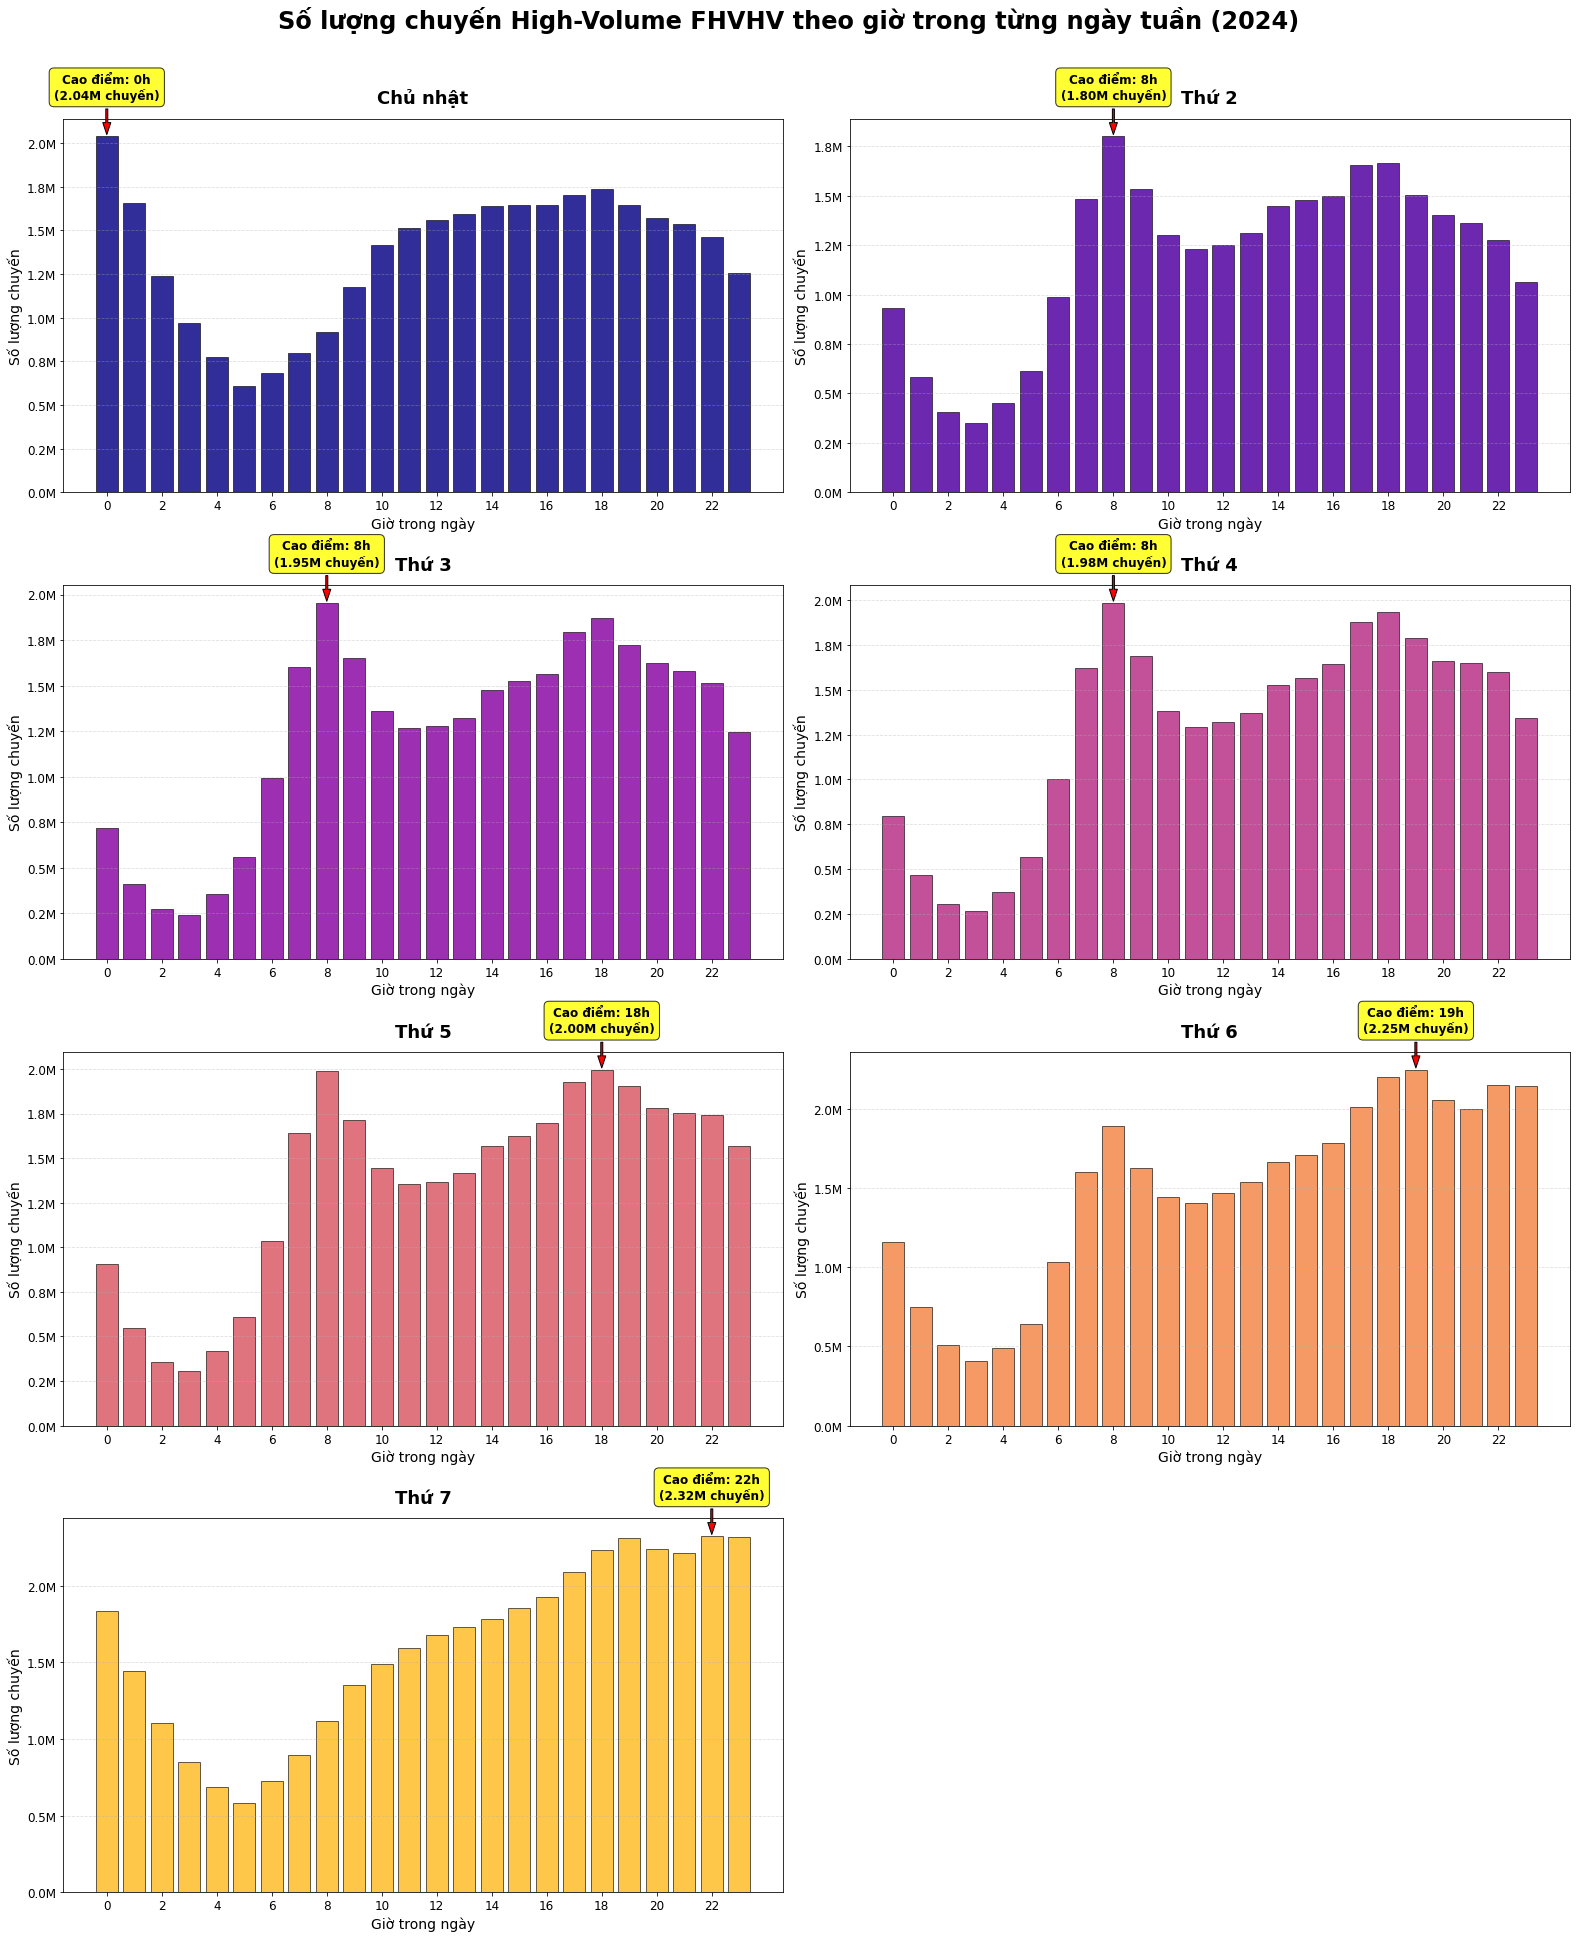

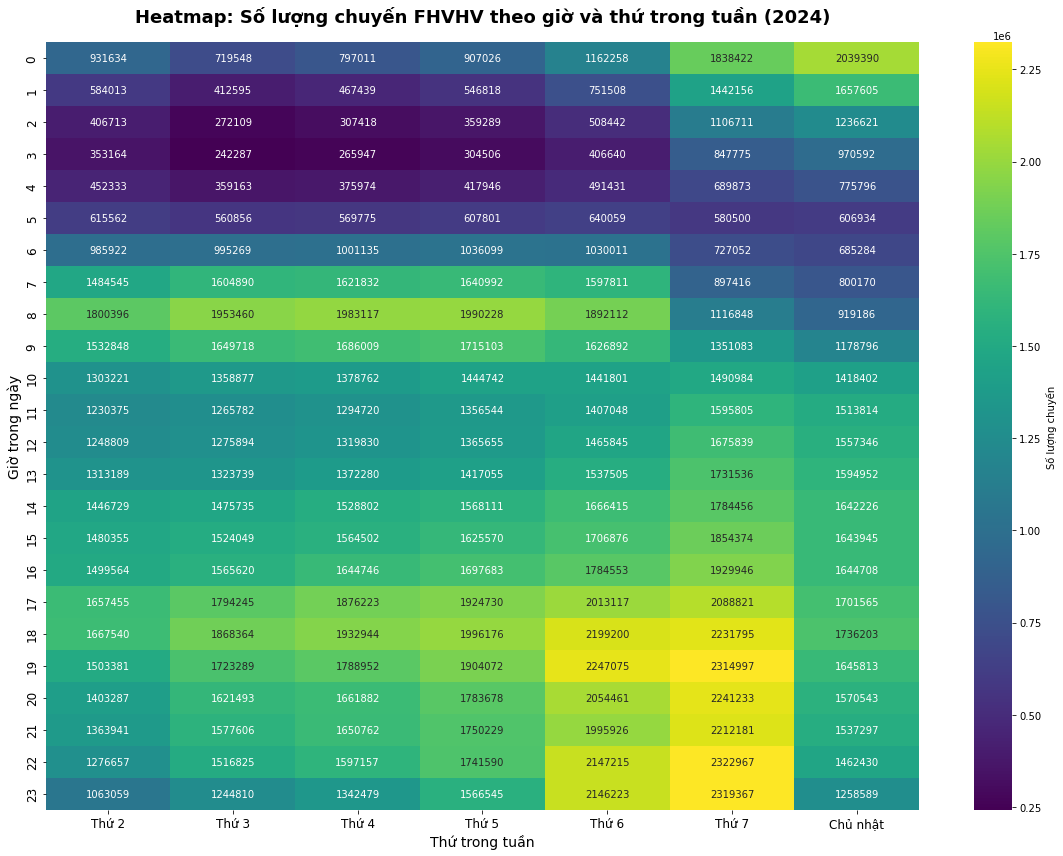

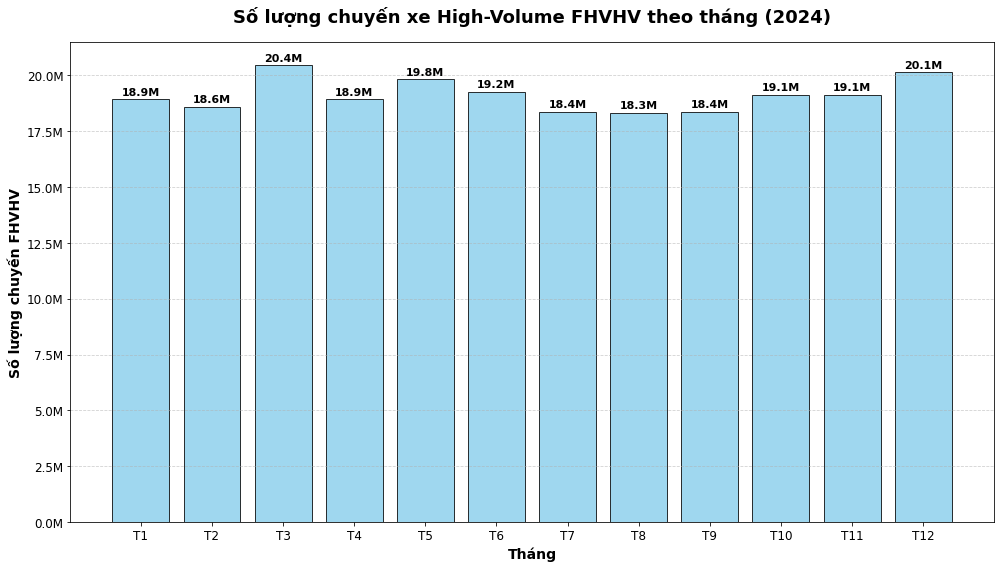


=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY ===

--- NGÀY TRONG TUẦN (THỨ 2-6) ---
Giờ cao điểm sáng: 8h (1,923,863 chuyến)
Giờ cao điểm chiều: 18h (1,932,845 chuyến)
Giờ thấp điểm: 3h (314,509 chuyến)

--- CUỐI TUẦN (CHỦ NHẬT, THỨ 7) ---
Giờ cao điểm sáng: 10h (1,454,693 chuyến)
Giờ cao điểm chiều: 18h (1,983,999 chuyến)
Giờ thấp điểm: 5h (593,717 chuyến)

=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN ===


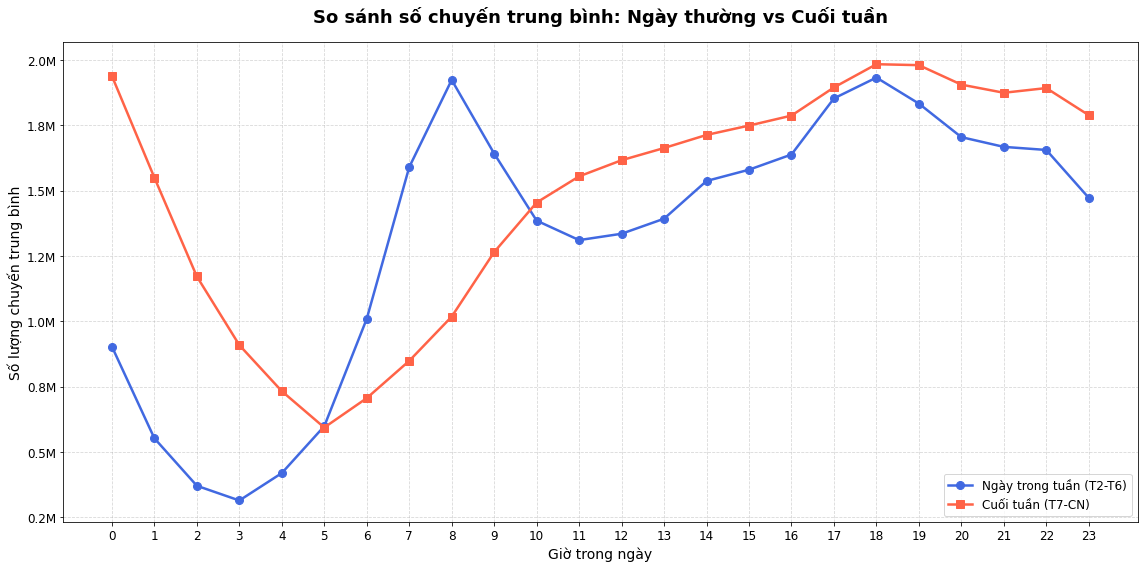


=== PHÂN TÍCH THỜI GIAN CHỜ TRUNG BÌNH ===
Số lượng chuyến có dữ liệu thời gian chờ hợp lệ: 227,156,120


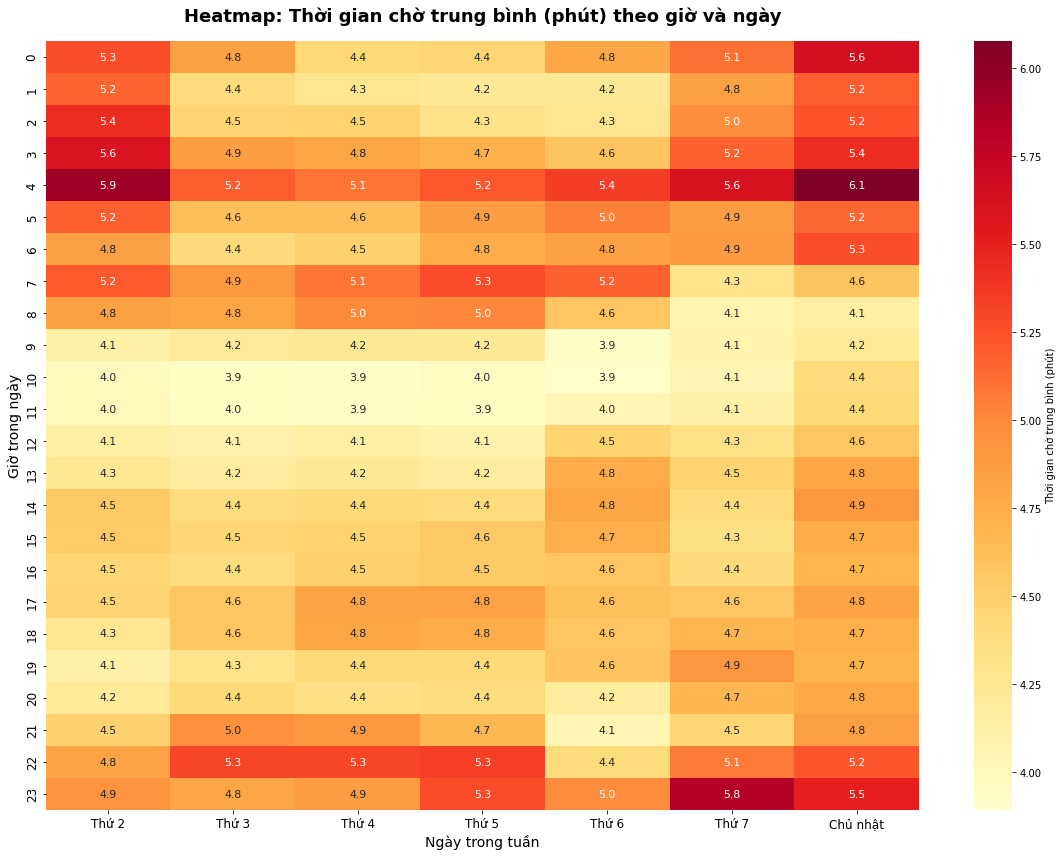


--- THỐNG KÊ TỔNG QUAN VỀ THỜI GIAN CHỜ ---
  summary   wait_time_minutes
0   count           227156120
1    mean  4.6307144900312736
2  stddev   2.907306316671641
3     min                 0.0
4     max                60.0

=== KẾT THÚC PHÂN TÍCH ===


In [10]:
from pyspark.sql.functions import col, hour, dayofweek, to_timestamp, unix_timestamp, month, avg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== PHÂN TÍCH HIGH-VOLUME: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (ĐẦY ĐỦ) ===")

# Đọc dữ liệu Parquet từ HDFS
df = spark.read.parquet("hdfs://master:9000/data/parquet/fhvhv_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu: {df.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU ---
df_filtered = df.filter(
    (col("pickup_datetime").isNotNull()) &
    (col("dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull()) &
    (col("trip_miles").isNotNull()) &
    (col("base_passenger_fare").isNotNull()) &
    (col("request_datetime").isNotNull()) # Thêm điều kiện lọc cho request_datetime
)
df_filtered = df_filtered.withColumn("pickup_ts", to_timestamp(col("pickup_datetime"))) \
                         .withColumn("dropoff_ts", to_timestamp(col("dropoff_datetime")))
df_filtered = df_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)
df_filtered = df_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)
df_filtered = df_filtered.filter(col("calculated_trip_time_seconds") > 0)
df_filtered = df_filtered.withColumn(
    "calculated_average_speed_mph",
    (col("trip_miles") / col("calculated_trip_time_seconds")) * 3600
)
df_filtered = df_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_miles") >= 0.1) & (col("trip_miles") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)
df_filtered = df_filtered.filter(
    (col("base_passenger_fare") >= 0) & (col("base_passenger_fare") < 1000) &
    (col("tolls") >= 0) & (col("tolls") < 200) &
    (col("bcf") >= 0) & (col("bcf") < 100) &
    (col("sales_tax") >= 0) & (col("sales_tax") < 100) &
    (col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20) &
    (col("airport_fee") >= 0) & (col("airport_fee") < 50) &
    (col("tips") >= 0) & (col("tips") < 300) &
    (col("driver_pay") >= 0) & (col("driver_pay") < 1000)
)

print(f"Tổng số dòng sau khi lọc: {df_filtered.count()}")

df_cleaned = df_filtered

# --- PHÂN TÍCH THEO NGÀY TRONG TUẦN ---
df_cleaned = df_cleaned.withColumn("hour", hour("pickup_ts")) \
                       .withColumn("weekday", dayofweek("pickup_ts"))

df_grouped = df_cleaned.groupBy("weekday", "hour").count().orderBy("weekday", "hour")
pdf_hourly = df_grouped.toPandas()

weekday_names = {1: "Chủ nhật", 2: "Thứ 2", 3: "Thứ 3", 4: "Thứ 4", 5: "Thứ 5", 6: "Thứ 6", 7: "Thứ 7"}

# === BIỂU ĐỒ CỘT THEO TỪNG NGÀY (ĐÃ CẢI TIẾN) ===
fig, axes = plt.subplots(4, 2, figsize=(22, 28))
fig.suptitle('Số lượng chuyến High-Volume FHVHV theo giờ trong từng ngày tuần (2024)',
             fontsize=24, fontweight='bold', y=0.96)
axes_flat = axes.flatten()
for i, (weekday_num, day_name) in enumerate(weekday_names.items()):
    day_data = pdf_hourly[pdf_hourly['weekday'] == weekday_num].sort_values('hour')
    ax = axes_flat[i]
    bars = ax.bar(day_data['hour'], day_data['count'],
                  color=plt.cm.plasma(i/7.0), alpha=0.85, edgecolor='black', linewidth=0.7)
    ax.set_title(day_name, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Giờ trong ngày', fontsize=14)
    ax.set_ylabel('Số lượng chuyến', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.4, axis='y', linestyle='--')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
    if not day_data.empty:
        peak_data = day_data.loc[day_data['count'].idxmax()]
        peak_hour, peak_count = peak_data['hour'], peak_data['count']
        ax.annotate(f'Cao điểm: {peak_hour}h\n({peak_count/1e6:.2f}M chuyến)',
                    xy=(peak_hour, peak_count),
                    xytext=(peak_hour, peak_count + ax.get_ylim()[1] * 0.1),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
                    fontsize=12, ha='center', color='black', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.4", fc="yellow", ec="black", lw=1, alpha=0.8))
axes_flat[7].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === HEATMAP TỔNG QUAN (ĐÃ CẢI TIẾN) ===
pdf_hourly_heatmap = pdf_hourly.copy()
pdf_hourly_heatmap["weekday_name"] = pdf_hourly_heatmap["weekday"].map(weekday_names)
pivot_df = pdf_hourly_heatmap.pivot(index="hour", columns="weekday_name", values="count").fillna(0)
pivot_df = pivot_df[["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]]
plt.figure(figsize=(16, 12))
sns.heatmap(pivot_df, cmap="viridis", annot=True, fmt=".0f",
            cbar_kws={'label': 'Số lượng chuyến'}, annot_kws={"size": 10})
plt.title("Heatmap: Số lượng chuyến FHVHV theo giờ và thứ trong tuần (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Thứ trong tuần", fontsize=14)
plt.ylabel("Giờ trong ngày", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# === PHÂN TÍCH THEO THÁNG (BIỂU ĐỒ CỘT ĐÃ CẢI TIẾN) ===
df_monthly_analysis = df_cleaned.withColumn("month", month("pickup_ts"))
df_monthly = df_monthly_analysis.groupBy("month").count().orderBy("month")
pdf_monthly = df_monthly.toPandas()
plt.figure(figsize=(14, 8))
bars = plt.bar(pdf_monthly["month"], pdf_monthly["count"], color='skyblue', edgecolor='black', alpha=0.8)
plt.xticks(pdf_monthly["month"], [f'T{m}' for m in pdf_monthly["month"]], fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Tháng", fontsize=14, fontweight='bold')
plt.ylabel("Số lượng chuyến FHVHV", fontsize=14, fontweight='bold')
plt.title("Số lượng chuyến xe High-Volume FHVHV theo tháng (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100000, f'{yval/1e6:.1f}M',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# === PHẦN CODE ĐƯỢC THÊM LẠI: SO SÁNH NGÀY THƯỜNG VS CUỐI TUẦN ===
print("\n=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY ===")
weekdays_working = [2, 3, 4, 5, 6]
weekdays_weekend = [1, 7]

def analyze_day_group(weekday_list, group_name):
    group_data = pdf_hourly[pdf_hourly['weekday'].isin(weekday_list)]
    hourly_avg = group_data.groupby('hour')['count'].mean().reset_index()
    print(f"\n--- {group_name.upper()} ---")
    if not hourly_avg.empty:
        morning_rush = hourly_avg[(hourly_avg['hour'] >= 6) & (hourly_avg['hour'] <= 10)]
        evening_rush = hourly_avg[(hourly_avg['hour'] >= 17) & (hourly_avg['hour'] <= 21)]
        if not morning_rush.empty:
            morning_peak = morning_rush.loc[morning_rush['count'].idxmax()]
            print(f"Giờ cao điểm sáng: {morning_peak['hour']:0.0f}h ({morning_peak['count']:,.0f} chuyến)")
        if not evening_rush.empty:
            evening_peak = evening_rush.loc[evening_rush['count'].idxmax()]
            print(f"Giờ cao điểm chiều: {evening_peak['hour']:0.0f}h ({evening_peak['count']:,.0f} chuyến)")
        low_peak = hourly_avg.loc[hourly_avg['count'].idxmin()]
        print(f"Giờ thấp điểm: {low_peak['hour']:0.0f}h ({low_peak['count']:,.0f} chuyến)")
    return hourly_avg

working_days_avg = analyze_day_group(weekdays_working, "Ngày trong tuần (Thứ 2-6)")
weekend_avg = analyze_day_group(weekdays_weekend, "Cuối tuần (Chủ nhật, Thứ 7)")

print("\n=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN ===")
plt.figure(figsize=(16, 8))
plt.plot(working_days_avg['hour'], working_days_avg['count'], marker='o', linewidth=2.5, color='royalblue', label='Ngày trong tuần (T2-T6)', markersize=8)
plt.plot(weekend_avg['hour'], weekend_avg['count'], marker='s', linewidth=2.5, color='tomato', label='Cuối tuần (T7-CN)', markersize=8)
plt.title('So sánh số chuyến trung bình: Ngày thường vs Cuối tuần', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Giờ trong ngày', fontsize=14)
plt.ylabel('Số lượng chuyến trung bình', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')
plt.xticks(range(0, 24, 1), fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# === PHẦN CODE ĐƯỢC THÊM LẠI: PHÂN TÍCH THỜI GIAN CHỜ TRUNG BÌNH ===
print("\n=== PHÂN TÍCH THỜI GIAN CHỜ TRUNG BÌNH ===")
df_wait_time = df_cleaned.withColumn(
    "wait_time_minutes",
    (unix_timestamp(col("pickup_ts")) - unix_timestamp(col("request_datetime"))) / 60
).filter(
    (col("wait_time_minutes") >= 0) & (col("wait_time_minutes") <= 60) # Lọc thời gian chờ hợp lý
)
print(f"Số lượng chuyến có dữ liệu thời gian chờ hợp lệ: {df_wait_time.count():,}")

wait_time_stats = df_wait_time.groupBy("weekday", "hour") \
    .agg(avg("wait_time_minutes").alias("avg_wait_time")) \
    .orderBy("weekday", "hour")

pdf_wait = wait_time_stats.toPandas()
pdf_wait['weekday_name'] = pdf_wait['weekday'].map(weekday_names)
wait_pivot = pdf_wait.pivot(index="hour", columns="weekday_name", values="avg_wait_time").fillna(0)
wait_pivot = wait_pivot[["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]]

plt.figure(figsize=(16, 12))
sns.heatmap(wait_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Thời gian chờ trung bình (phút)'}, annot_kws={"size": 11})
plt.title('Heatmap: Thời gian chờ trung bình (phút) theo giờ và ngày',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Ngày trong tuần', fontsize=14)
plt.ylabel('Giờ trong ngày', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

overall_wait_stats = df_wait_time.select("wait_time_minutes").describe().toPandas()
print("\n--- THỐNG KÊ TỔNG QUAN VỀ THỜI GIAN CHỜ ---")
print(overall_wait_stats)

print("\n=== KẾT THÚC PHÂN TÍCH ===")


=== PHÂN TÍCH YELLOW TAXI: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (CẢI TIẾN) ===
Tổng số dòng ban đầu: 41169720
Tổng số dòng sau khi lọc: 39107370


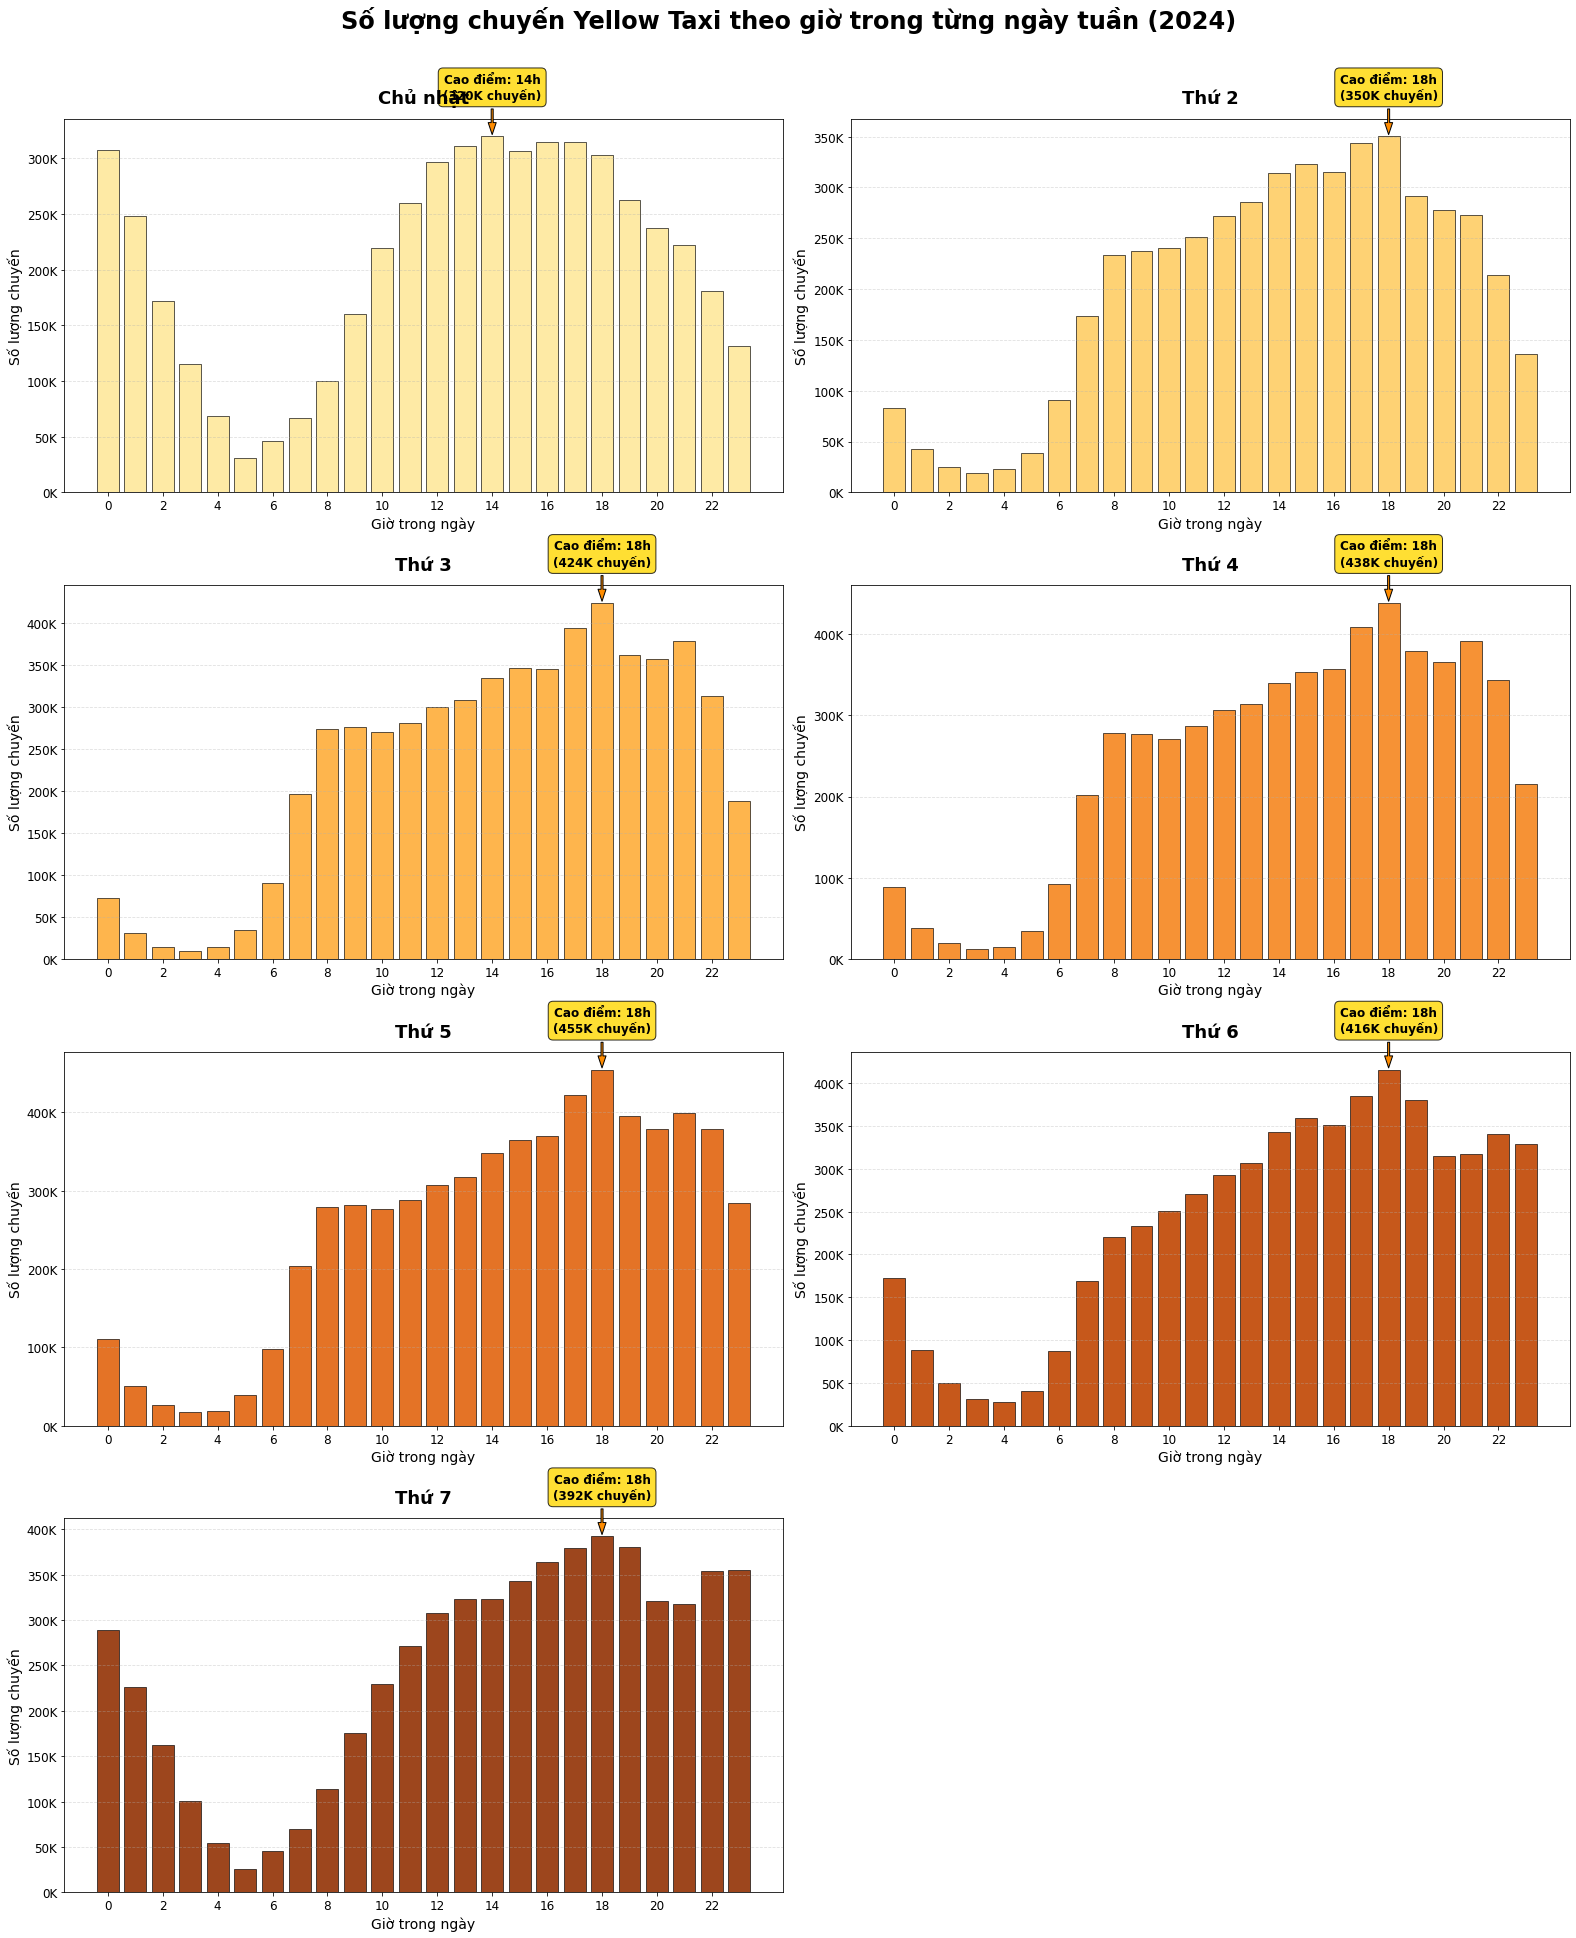

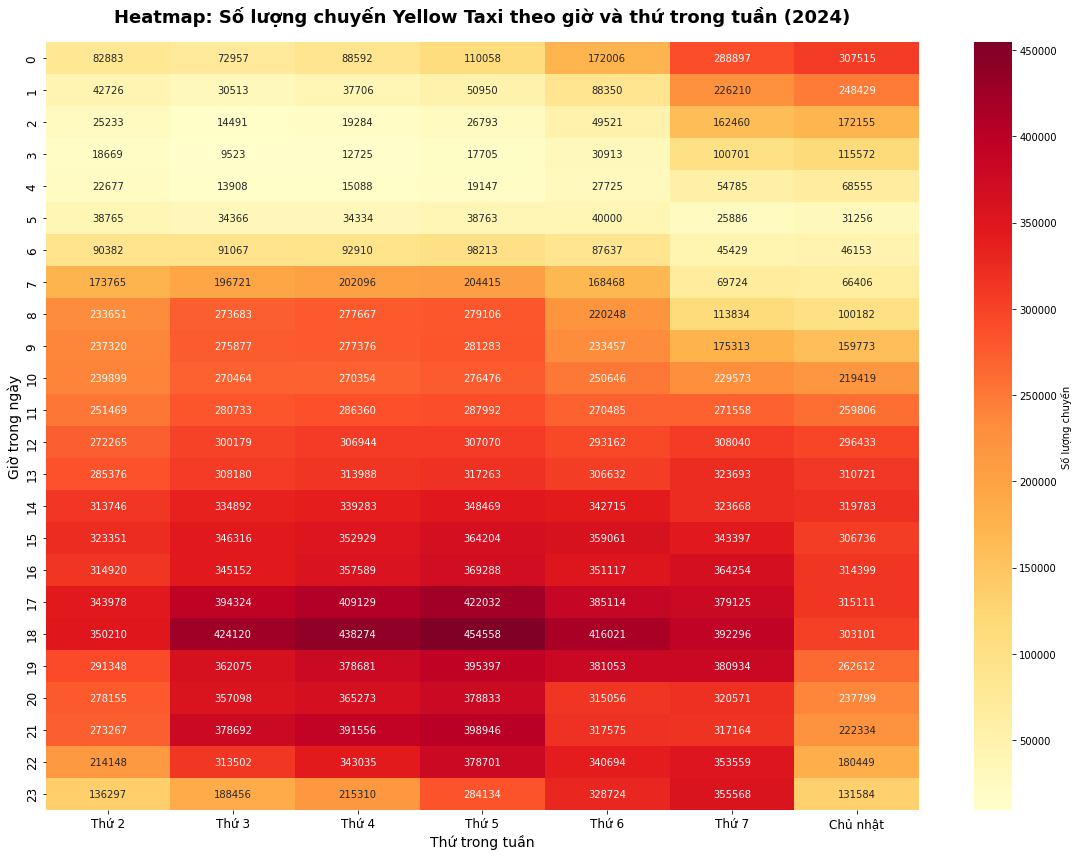


=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY (YELLOW TAXI) ===

--- NGÀY TRONG TUẦN (THỨ 2-6) ---
Giờ cao điểm sáng: 10h (261,568 chuyến)
Giờ cao điểm chiều: 18h (416,637 chuyến)
Giờ thấp điểm: 3h (17,907 chuyến)

--- CUỐI TUẦN (CHỦ NHẬT, THỨ 7) ---
Giờ cao điểm sáng: 10h (224,496 chuyến)
Giờ cao điểm chiều: 18h (347,698 chuyến)
Giờ thấp điểm: 5h (28,571 chuyến)

=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN (YELLOW TAXI) ===


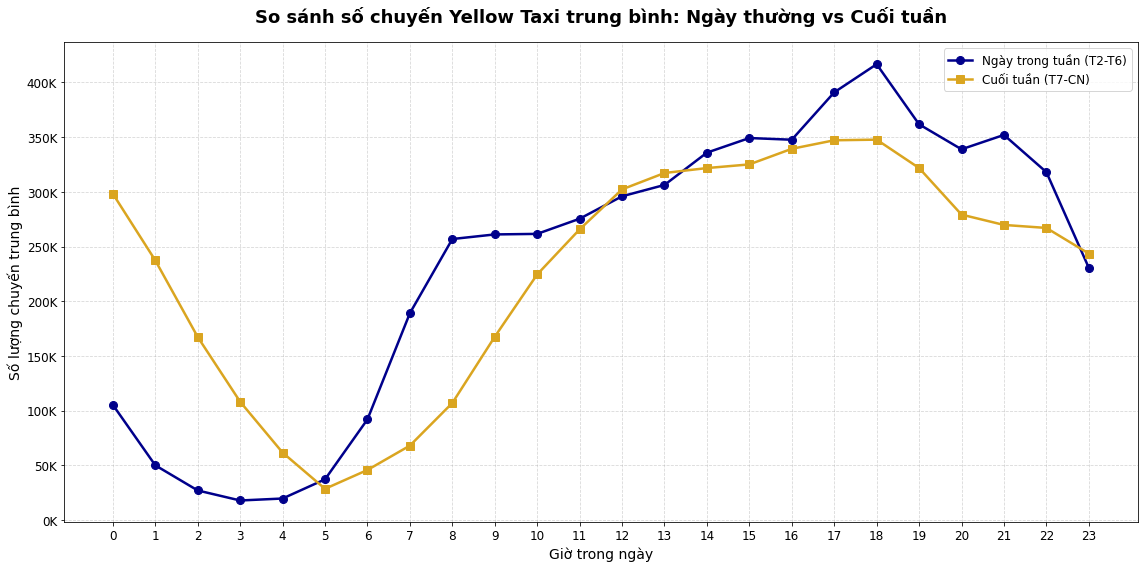


=== PHÂN TÍCH THEO THÁNG (YELLOW TAXI) ===


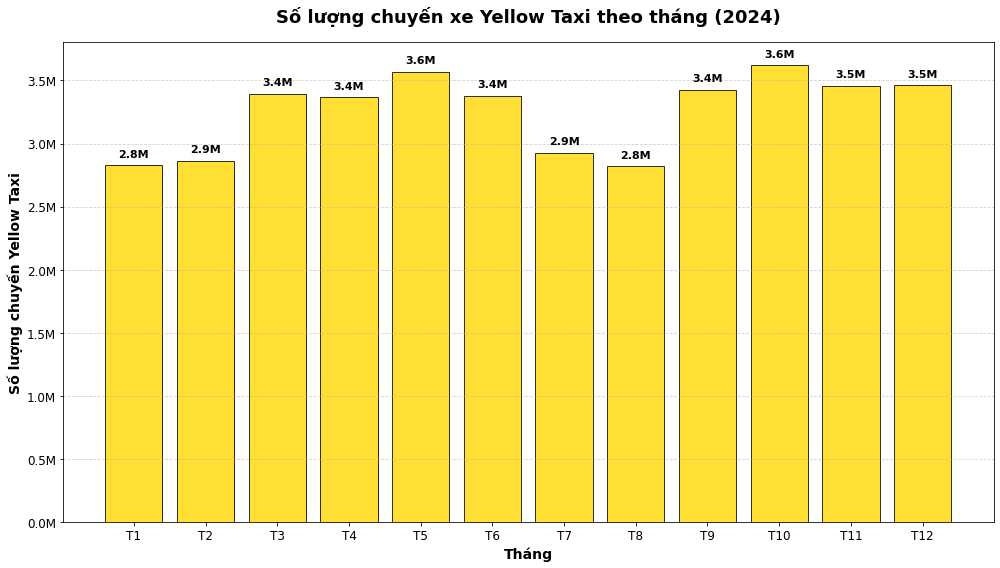


=== KẾT THÚC PHÂN TÍCH YELLOW TAXI ===


In [11]:
from pyspark.sql.functions import col, hour, dayofweek, to_timestamp, unix_timestamp, month, avg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== PHÂN TÍCH YELLOW TAXI: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (CẢI TIẾN) ===")

# Đọc dữ liệu Parquet từ HDFS cho Yellow Taxi
df = spark.read.parquet("hdfs://master:9000/data/parquet/yellow_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu: {df.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU (Đã điều chỉnh cho Yellow Taxi) ---
df_filtered = df.filter(
    (col("tpep_pickup_datetime").isNotNull()) &
    (col("tpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull()) &
    (col("trip_distance").isNotNull()) &
    (col("fare_amount").isNotNull())
)
df_filtered = df_filtered.withColumn("pickup_ts", to_timestamp(col("tpep_pickup_datetime"))) \
                         .withColumn("dropoff_ts", to_timestamp(col("tpep_dropoff_datetime")))

df_filtered = df_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_filtered = df_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)
df_filtered = df_filtered.filter(col("calculated_trip_time_seconds") > 0)

df_filtered = df_filtered.withColumn(
    "calculated_average_speed_mph",
    (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600
)

df_filtered = df_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

# Lọc các giá trị tài chính hợp lệ cho Yellow Taxi
df_filtered = df_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("congestion_surcharge").isNull() | ((col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300)
)

print(f"Tổng số dòng sau khi lọc: {df_filtered.count()}")

df_cleaned = df_filtered

# --- PHÂN TÍCH THEO NGÀY TRONG TUẦN ---
df_cleaned = df_cleaned.withColumn("hour", hour("pickup_ts")) \
                       .withColumn("weekday", dayofweek("pickup_ts"))

df_grouped = df_cleaned.groupBy("weekday", "hour").count().orderBy("weekday", "hour")
pdf_hourly = df_grouped.toPandas()

weekday_names = {1: "Chủ nhật", 2: "Thứ 2", 3: "Thứ 3", 4: "Thứ 4", 5: "Thứ 5", 6: "Thứ 6", 7: "Thứ 7"}

# === BIỂU ĐỒ CỘT THEO TỪNG NGÀY (ĐÃ CẢI TIẾN) ===
fig, axes = plt.subplots(4, 2, figsize=(22, 28))
fig.suptitle('Số lượng chuyến Yellow Taxi theo giờ trong từng ngày tuần (2024)',
             fontsize=24, fontweight='bold', y=0.96)
axes_flat = axes.flatten()

for i, (weekday_num, day_name) in enumerate(weekday_names.items()):
    day_data = pdf_hourly[pdf_hourly['weekday'] == weekday_num].sort_values('hour')
    ax = axes_flat[i]
    
    # Sử dụng màu vàng/cam cho Yellow Taxi
    bars = ax.bar(day_data['hour'], day_data['count'],
                  color=plt.cm.YlOrBr((i+2)/9.0), alpha=0.9, edgecolor='black', linewidth=0.7)
    
    ax.set_title(day_name, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Giờ trong ngày', fontsize=14)
    ax.set_ylabel('Số lượng chuyến', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.4, axis='y', linestyle='--')
    # Định dạng trục Y theo nghìn (K)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    if not day_data.empty:
        peak_data = day_data.loc[day_data['count'].idxmax()]
        peak_hour, peak_count = peak_data['hour'], peak_data['count']
        
        ax.annotate(f'Cao điểm: {peak_hour}h\n({peak_count/1000:.0f}K chuyến)',
                    xy=(peak_hour, peak_count),
                    xytext=(peak_hour, peak_count + ax.get_ylim()[1] * 0.1),
                    arrowprops=dict(facecolor='darkorange', shrink=0.05, width=2, headwidth=8),
                    fontsize=12, ha='center', color='black', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.4", fc="gold", ec="black", lw=1, alpha=0.8))

axes_flat[7].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === HEATMAP TỔNG QUAN (ĐÃ CẢI TIẾN) ===
pdf_hourly_heatmap = pdf_hourly.copy()
pdf_hourly_heatmap["weekday_name"] = pdf_hourly_heatmap["weekday"].map(weekday_names)
pivot_df = pdf_hourly_heatmap.pivot(index="hour", columns="weekday_name", values="count").fillna(0)
pivot_df = pivot_df[["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]]

plt.figure(figsize=(16, 12))
sns.heatmap(pivot_df, cmap="YlOrRd", annot=True, fmt=".0f",
            cbar_kws={'label': 'Số lượng chuyến'}, annot_kws={"size": 10})
plt.title("Heatmap: Số lượng chuyến Yellow Taxi theo giờ và thứ trong tuần (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Thứ trong tuần", fontsize=14)
plt.ylabel("Giờ trong ngày", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# === PHÂN TÍCH THỐNG KÊ VÀ SO SÁNH NGÀY THƯỜNG/CUỐI TUẦN ===
print("\n=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY (YELLOW TAXI) ===")
weekdays_working = [2, 3, 4, 5, 6]
weekdays_weekend = [1, 7]

def analyze_day_group(weekday_list, group_name):
    group_data = pdf_hourly[pdf_hourly['weekday'].isin(weekday_list)]
    hourly_avg = group_data.groupby('hour')['count'].mean().reset_index()
    print(f"\n--- {group_name.upper()} ---")
    if not hourly_avg.empty:
        morning_rush = hourly_avg[(hourly_avg['hour'] >= 6) & (hourly_avg['hour'] <= 10)]
        evening_rush = hourly_avg[(hourly_avg['hour'] >= 17) & (hourly_avg['hour'] <= 21)]
        if not morning_rush.empty:
            morning_peak = morning_rush.loc[morning_rush['count'].idxmax()]
            print(f"Giờ cao điểm sáng: {morning_peak['hour']:0.0f}h ({morning_peak['count']:,.0f} chuyến)")
        if not evening_rush.empty:
            evening_peak = evening_rush.loc[evening_rush['count'].idxmax()]
            print(f"Giờ cao điểm chiều: {evening_peak['hour']:0.0f}h ({evening_peak['count']:,.0f} chuyến)")
        low_peak = hourly_avg.loc[hourly_avg['count'].idxmin()]
        print(f"Giờ thấp điểm: {low_peak['hour']:0.0f}h ({low_peak['count']:,.0f} chuyến)")
    return hourly_avg

working_days_avg = analyze_day_group(weekdays_working, "Ngày trong tuần (Thứ 2-6)")
weekend_avg = analyze_day_group(weekdays_weekend, "Cuối tuần (Chủ nhật, Thứ 7)")

print("\n=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN (YELLOW TAXI) ===")
plt.figure(figsize=(16, 8))
plt.plot(working_days_avg['hour'], working_days_avg['count'], marker='o', linewidth=2.5, color='darkblue', label='Ngày trong tuần (T2-T6)', markersize=8)
plt.plot(weekend_avg['hour'], weekend_avg['count'], marker='s', linewidth=2.5, color='goldenrod', label='Cuối tuần (T7-CN)', markersize=8)
plt.title('So sánh số chuyến Yellow Taxi trung bình: Ngày thường vs Cuối tuần', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Giờ trong ngày', fontsize=14)
plt.ylabel('Số lượng chuyến trung bình', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')
plt.xticks(range(0, 24, 1), fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()


# === PHÂN TÍCH THEO THÁNG (BIỂU ĐỒ CỘT ĐÃ CẢI TIẾN) ===
print("\n=== PHÂN TÍCH THEO THÁNG (YELLOW TAXI) ===")
df_monthly_analysis = df_cleaned.withColumn("month", month("pickup_ts"))
df_monthly = df_monthly_analysis.groupBy("month").count().orderBy("month")
pdf_monthly = df_monthly.toPandas()

plt.figure(figsize=(14, 8))
bars = plt.bar(pdf_monthly["month"], pdf_monthly["count"], color='gold', edgecolor='black', alpha=0.8)
plt.xticks(pdf_monthly["month"], [f'T{m}' for m in pdf_monthly["month"]], fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Tháng", fontsize=14, fontweight='bold')
plt.ylabel("Số lượng chuyến Yellow Taxi", fontsize=14, fontweight='bold')
plt.title("Số lượng chuyến xe Yellow Taxi theo tháng (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50000, f'{yval/1e6:.1f}M',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== KẾT THÚC PHÂN TÍCH YELLOW TAXI ===")


=== PHÂN TÍCH GREEN TAXI: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (CẢI TIẾN) ===
Tổng số dòng ban đầu: 660218
Tổng số dòng sau khi lọc: 608818


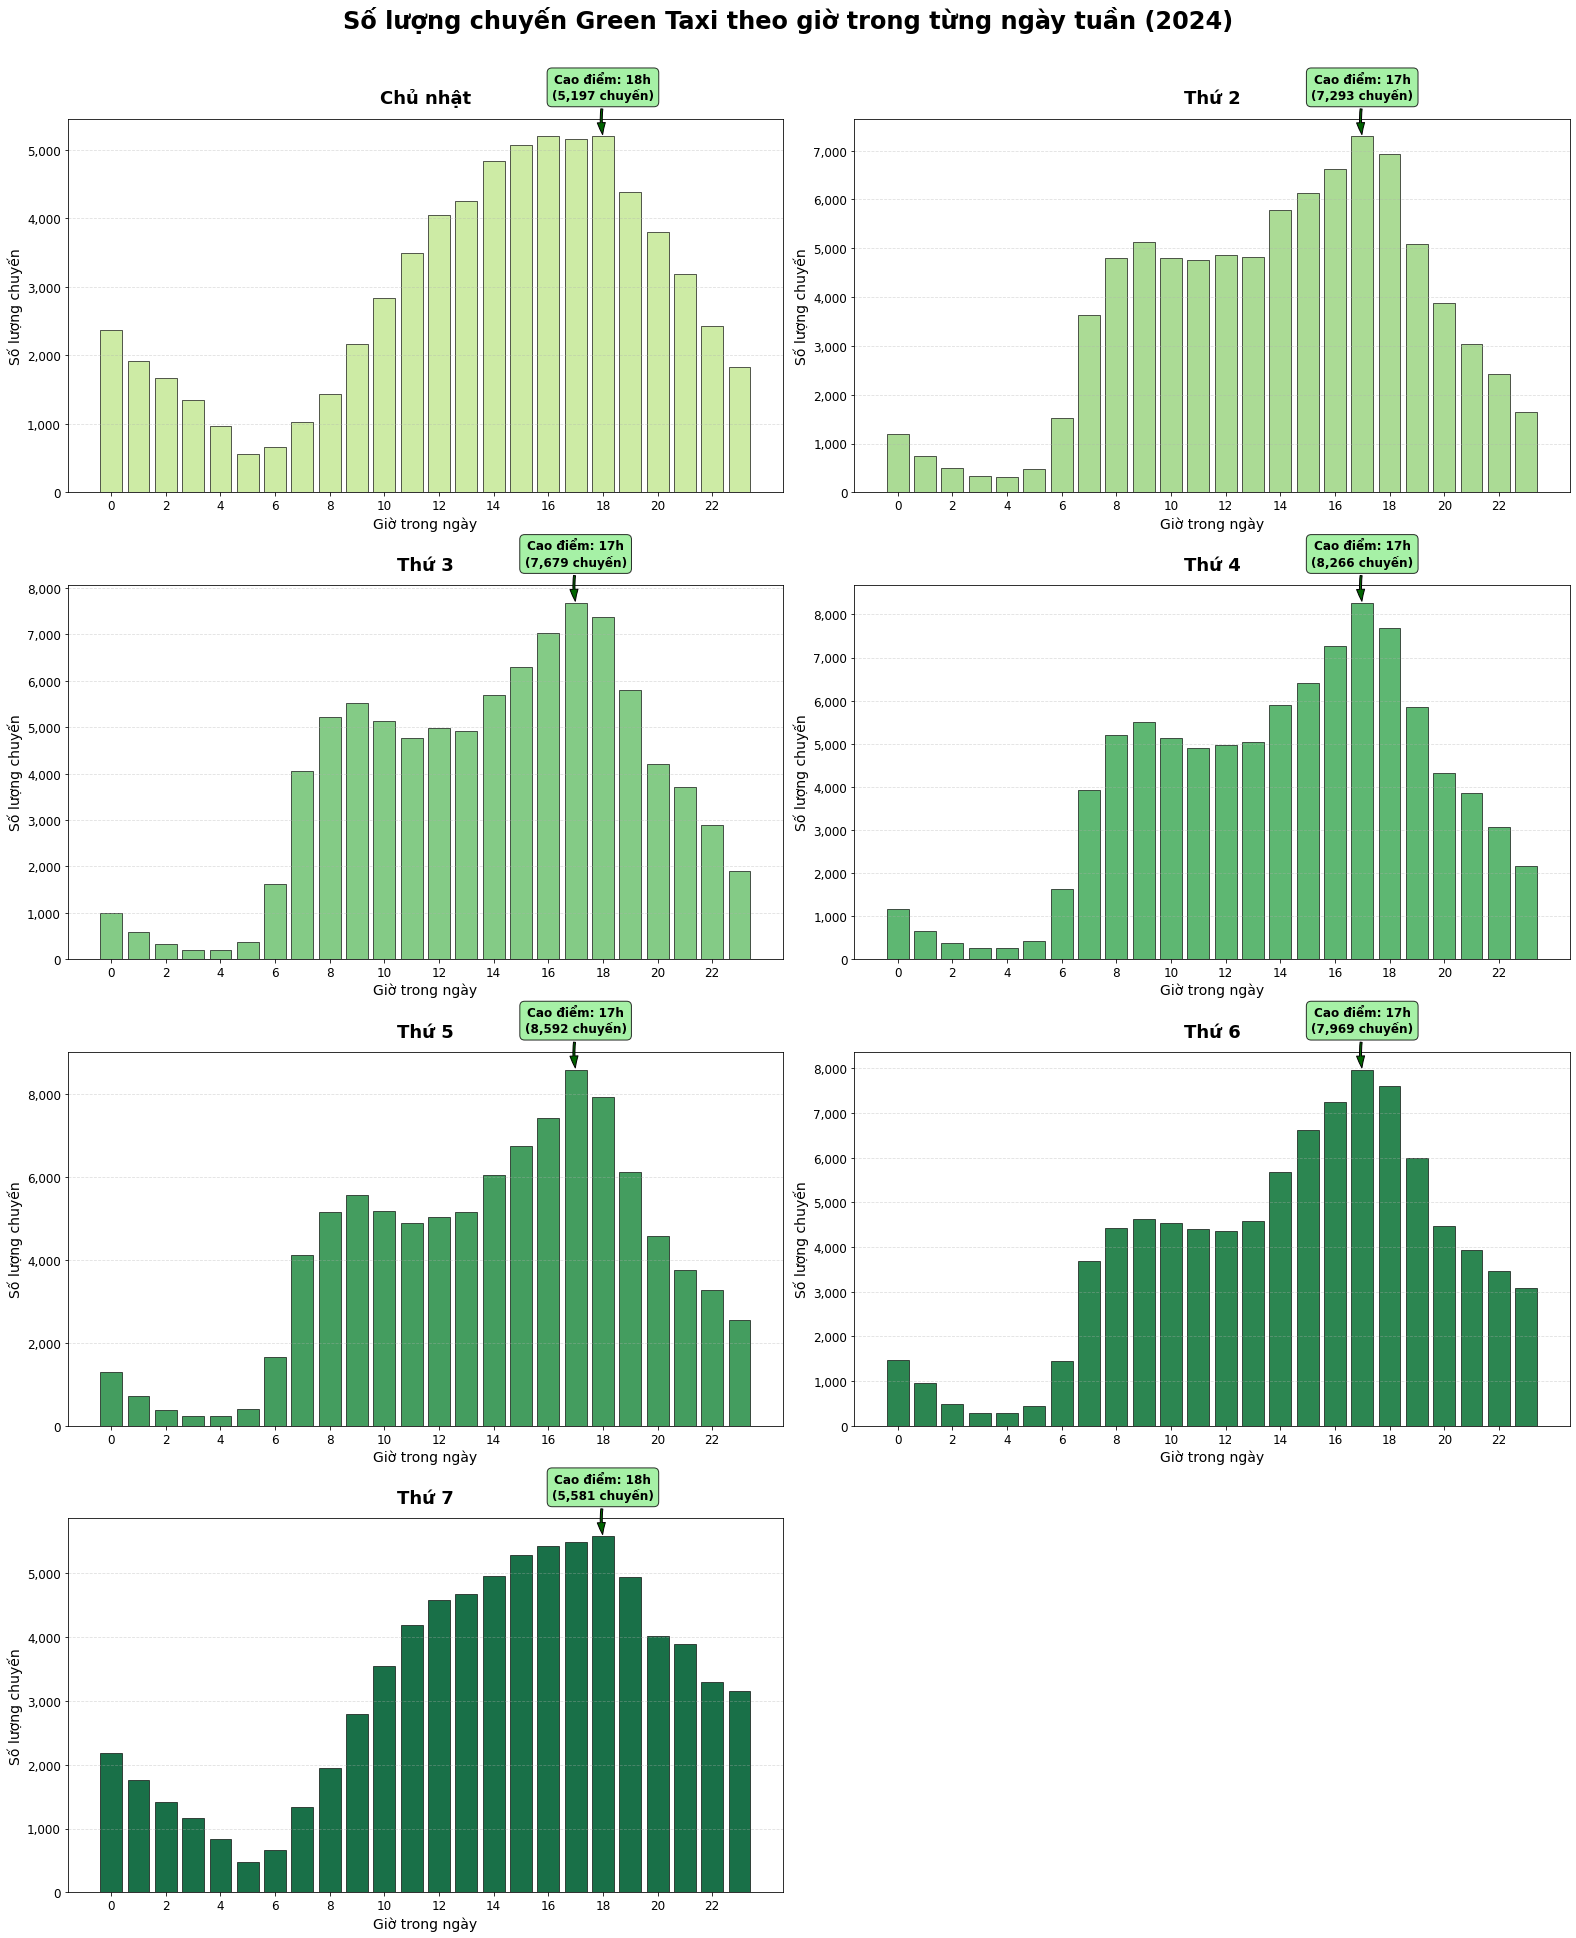

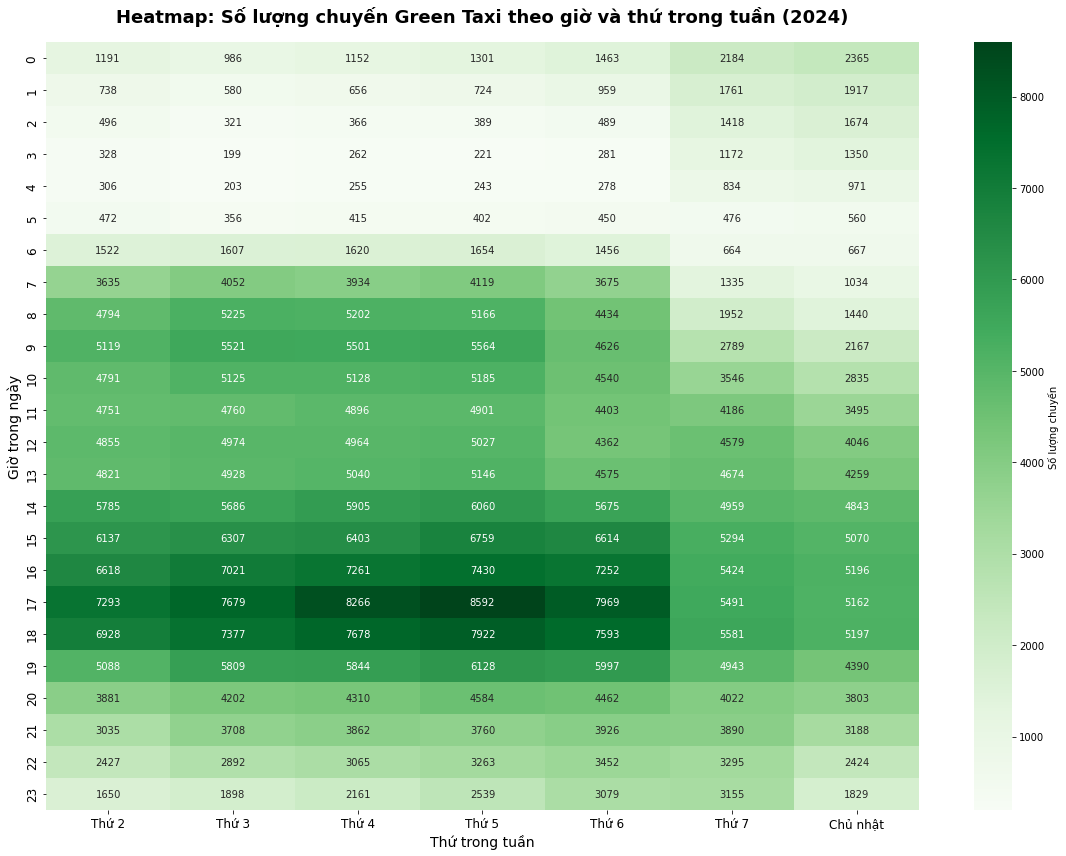


=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY (GREEN TAXI) ===

--- NGÀY TRONG TUẦN (THỨ 2-6) ---
Giờ cao điểm sáng: 9h (5,266 chuyến)
Giờ cao điểm chiều: 17h (7,960 chuyến)
Giờ thấp điểm: 4h (257 chuyến)

--- CUỐI TUẦN (CHỦ NHẬT, THỨ 7) ---
Giờ cao điểm sáng: 10h (3,190 chuyến)
Giờ cao điểm chiều: 18h (5,389 chuyến)
Giờ thấp điểm: 5h (518 chuyến)

=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN (GREEN TAXI) ===


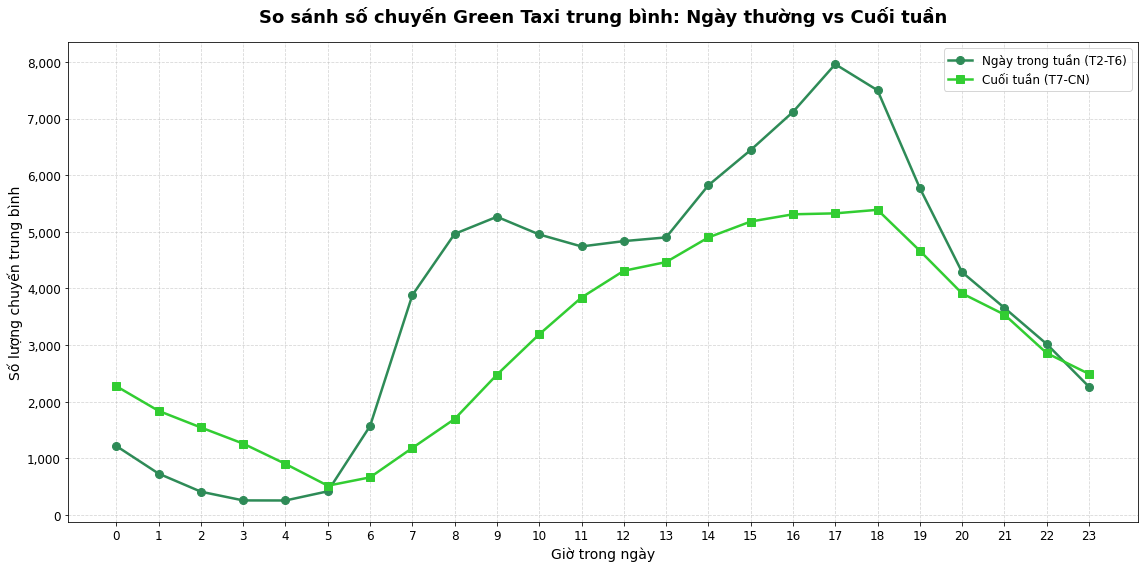


=== PHÂN TÍCH THEO THÁNG (GREEN TAXI) ===


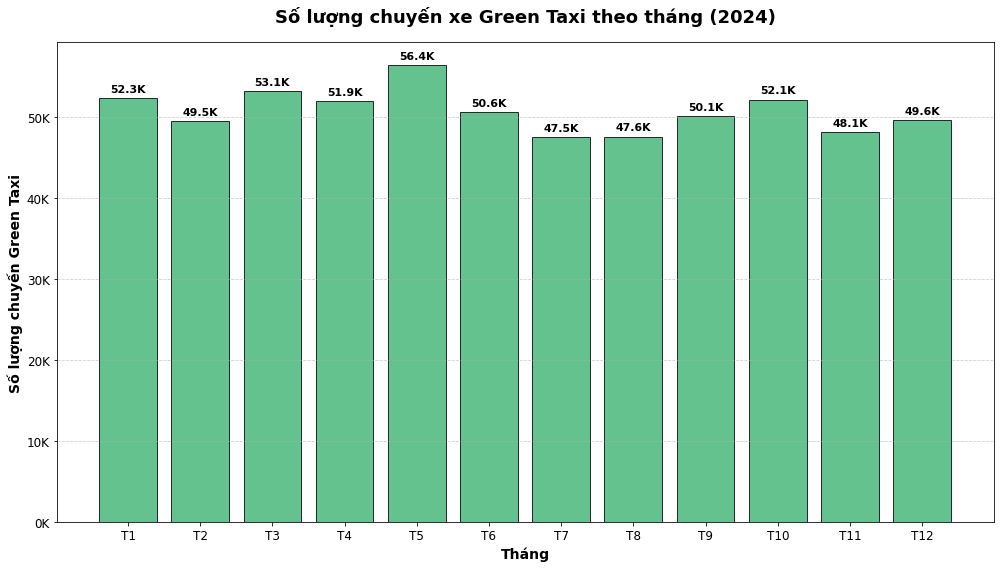


=== KẾT THÚC PHÂN TÍCH GREEN TAXI ===


In [12]:
from pyspark.sql.functions import col, hour, dayofweek, to_timestamp, unix_timestamp, month, avg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== PHÂN TÍCH GREEN TAXI: MẪU HÌNH THEO TỪNG NGÀY TRONG TUẦN (CẢI TIẾN) ===")

# Đọc dữ liệu Parquet từ HDFS cho Green Taxi
df = spark.read.parquet("hdfs://master:9000/data/parquet/green_tripdata_2024-*.parquet")

print(f"Tổng số dòng ban đầu: {df.count()}")

# --- BẮT ĐẦU CÁC BƯỚC LỌC DỮ LIỆU (Đã điều chỉnh cho Green Taxi) ---
df_filtered = df.filter(
    (col("lpep_pickup_datetime").isNotNull()) &
    (col("lpep_dropoff_datetime").isNotNull()) &
    (col("PULocationID").isNotNull()) &
    (col("DOLocationID").isNotNull()) &
    (col("trip_distance").isNotNull()) &
    (col("fare_amount").isNotNull())
)
df_filtered = df_filtered.withColumn("pickup_ts", to_timestamp(col("lpep_pickup_datetime"))) \
                         .withColumn("dropoff_ts", to_timestamp(col("lpep_dropoff_datetime")))

df_filtered = df_filtered.filter(
    (col("PULocationID") > 0) & (col("PULocationID") <= 263) &
    (col("DOLocationID") > 0) & (col("DOLocationID") <= 263)
)

df_filtered = df_filtered.withColumn(
    "calculated_trip_time_seconds",
    unix_timestamp(col("dropoff_ts")) - unix_timestamp(col("pickup_ts"))
)
df_filtered = df_filtered.filter(col("calculated_trip_time_seconds") > 0)

df_filtered = df_filtered.withColumn(
    "calculated_average_speed_mph",
    (col("trip_distance") / col("calculated_trip_time_seconds")) * 3600
)

df_filtered = df_filtered.filter(
    (col("calculated_trip_time_seconds") >= 60) & (col("calculated_trip_time_seconds") <= 18000) &
    (col("trip_distance") >= 0.1) & (col("trip_distance") <= 50) &
    (col("calculated_average_speed_mph") >= 1) & (col("calculated_average_speed_mph") <= 60)
)

# Lọc các giá trị tài chính hợp lệ cho Green Taxi
df_filtered = df_filtered.filter(
    (col("fare_amount") >= 0) & (col("fare_amount") < 1000) &
    (col("tolls_amount") >= 0) & (col("tolls_amount") < 200) &
    (col("congestion_surcharge").isNull() | ((col("congestion_surcharge") >= 0) & (col("congestion_surcharge") < 20))) &
    (col("tip_amount") >= 0) & (col("tip_amount") < 300)
)

print(f"Tổng số dòng sau khi lọc: {df_filtered.count()}")

df_cleaned = df_filtered

# --- PHÂN TÍCH THEO NGÀY TRONG TUẦN ---
df_cleaned = df_cleaned.withColumn("hour", hour("pickup_ts")) \
                       .withColumn("weekday", dayofweek("pickup_ts"))

df_grouped = df_cleaned.groupBy("weekday", "hour").count().orderBy("weekday", "hour")
pdf_hourly = df_grouped.toPandas()

weekday_names = {1: "Chủ nhật", 2: "Thứ 2", 3: "Thứ 3", 4: "Thứ 4", 5: "Thứ 5", 6: "Thứ 6", 7: "Thứ 7"}

# === BIỂU ĐỒ CỘT THEO TỪNG NGÀY (ĐÃ CẢI TIẾN) ===
fig, axes = plt.subplots(4, 2, figsize=(22, 28))
fig.suptitle('Số lượng chuyến Green Taxi theo giờ trong từng ngày tuần (2024)',
             fontsize=24, fontweight='bold', y=0.96)
axes_flat = axes.flatten()

for i, (weekday_num, day_name) in enumerate(weekday_names.items()):
    day_data = pdf_hourly[pdf_hourly['weekday'] == weekday_num].sort_values('hour')
    ax = axes_flat[i]
    
    # Sử dụng màu xanh lá cho Green Taxi
    bars = ax.bar(day_data['hour'], day_data['count'],
                  color=plt.cm.YlGn((i+3)/10.0), alpha=0.9, edgecolor='black', linewidth=0.7)
    
    ax.set_title(day_name, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Giờ trong ngày', fontsize=14)
    ax.set_ylabel('Số lượng chuyến', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.4, axis='y', linestyle='--')
    # Định dạng trục Y theo số đầy đủ vì số lượng không quá lớn
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    if not day_data.empty:
        peak_data = day_data.loc[day_data['count'].idxmax()]
        peak_hour, peak_count = peak_data['hour'], peak_data['count']
        
        ax.annotate(f'Cao điểm: {peak_hour}h\n({peak_count:,.0f} chuyến)',
                    xy=(peak_hour, peak_count),
                    xytext=(peak_hour, peak_count + ax.get_ylim()[1] * 0.1),
                    arrowprops=dict(facecolor='darkgreen', shrink=0.05, width=2, headwidth=8, connectionstyle="arc3,rad=0.1"),
                    fontsize=12, ha='center', color='black', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.4", fc="lightgreen", ec="black", lw=1, alpha=0.8))

axes_flat[7].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === HEATMAP TỔNG QUAN (ĐÃ CẢI TIẾN) ===
pdf_hourly_heatmap = pdf_hourly.copy()
pdf_hourly_heatmap["weekday_name"] = pdf_hourly_heatmap["weekday"].map(weekday_names)
pivot_df = pdf_hourly_heatmap.pivot(index="hour", columns="weekday_name", values="count").fillna(0)
pivot_df = pivot_df[["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]]

plt.figure(figsize=(16, 12))
sns.heatmap(pivot_df, cmap="Greens", annot=True, fmt=".0f",
            cbar_kws={'label': 'Số lượng chuyến'}, annot_kws={"size": 10})
plt.title("Heatmap: Số lượng chuyến Green Taxi theo giờ và thứ trong tuần (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Thứ trong tuần", fontsize=14)
plt.ylabel("Giờ trong ngày", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# === PHÂN TÍCH THỐNG KÊ VÀ SO SÁNH NGÀY THƯỜNG/CUỐI TUẦN ===
print("\n=== PHÂN TÍCH THỐNG KÊ CHI TIẾT THEO NHÓM NGÀY (GREEN TAXI) ===")
weekdays_working = [2, 3, 4, 5, 6]
weekdays_weekend = [1, 7]

def analyze_day_group(weekday_list, group_name):
    group_data = pdf_hourly[pdf_hourly['weekday'].isin(weekday_list)]
    hourly_avg = group_data.groupby('hour')['count'].mean().reset_index()
    print(f"\n--- {group_name.upper()} ---")
    if not hourly_avg.empty:
        morning_rush = hourly_avg[(hourly_avg['hour'] >= 6) & (hourly_avg['hour'] <= 10)]
        evening_rush = hourly_avg[(hourly_avg['hour'] >= 17) & (hourly_avg['hour'] <= 21)]
        if not morning_rush.empty:
            morning_peak = morning_rush.loc[morning_rush['count'].idxmax()]
            print(f"Giờ cao điểm sáng: {morning_peak['hour']:0.0f}h ({morning_peak['count']:,.0f} chuyến)")
        if not evening_rush.empty:
            evening_peak = evening_rush.loc[evening_rush['count'].idxmax()]
            print(f"Giờ cao điểm chiều: {evening_peak['hour']:0.0f}h ({evening_peak['count']:,.0f} chuyến)")
        low_peak = hourly_avg.loc[hourly_avg['count'].idxmin()]
        print(f"Giờ thấp điểm: {low_peak['hour']:0.0f}h ({low_peak['count']:,.0f} chuyến)")
    return hourly_avg

working_days_avg = analyze_day_group(weekdays_working, "Ngày trong tuần (Thứ 2-6)")
weekend_avg = analyze_day_group(weekdays_weekend, "Cuối tuần (Chủ nhật, Thứ 7)")

print("\n=== SO SÁNH MẪU HÌNH NGÀY TRONG TUẦN VS CUỐI TUẦN (GREEN TAXI) ===")
plt.figure(figsize=(16, 8))
plt.plot(working_days_avg['hour'], working_days_avg['count'], marker='o', linewidth=2.5, color='seagreen', label='Ngày trong tuần (T2-T6)', markersize=8)
plt.plot(weekend_avg['hour'], weekend_avg['count'], marker='s', linewidth=2.5, color='limegreen', label='Cuối tuần (T7-CN)', markersize=8)
plt.title('So sánh số chuyến Green Taxi trung bình: Ngày thường vs Cuối tuần', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Giờ trong ngày', fontsize=14)
plt.ylabel('Số lượng chuyến trung bình', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')
plt.xticks(range(0, 24, 1), fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# === PHÂN TÍCH THEO THÁNG (BIỂU ĐỒ CỘT ĐÃ CẢI TIẾN) ===
print("\n=== PHÂN TÍCH THEO THÁNG (GREEN TAXI) ===")
df_monthly_analysis = df_cleaned.withColumn("month", month("pickup_ts"))
df_monthly = df_monthly_analysis.groupBy("month").count().orderBy("month")
pdf_monthly = df_monthly.toPandas()

plt.figure(figsize=(14, 8))
bars = plt.bar(pdf_monthly["month"], pdf_monthly["count"], color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xticks(pdf_monthly["month"], [f'T{m}' for m in pdf_monthly["month"]], fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Tháng", fontsize=14, fontweight='bold')
plt.ylabel("Số lượng chuyến Green Taxi", fontsize=14, fontweight='bold')
plt.title("Số lượng chuyến xe Green Taxi theo tháng (2024)",
          fontsize=18, fontweight='bold', pad=20)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, f'{yval/1000:.1f}K',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== KẾT THÚC PHÂN TÍCH GREEN TAXI ===")
